# Inicialização

## Import de bibliotecas

In [1]:
import os
import pandas as pd
import numpy as np
import collections
import seaborn as sns
import joblib
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
from pprint import pprint

# from google.colab import drive

from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.transforms import Bbox
from matplotlib.ticker import MaxNLocator

from sklearn import svm, tree
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

from sklearn.model_selection import cross_val_score, cross_val_predict, train_test_split, StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score,accuracy_score,roc_curve,\
classification_report,confusion_matrix,auc
from sklearn.preprocessing import label_binarize

pd.set_option('max_colwidth', 800)

## Setup de plotagem de gráficos

In [2]:
rotas = {
    1: { 'cor': '#00bf63', 'nome': 'Verde' },
    2: { 'cor': '#ff3131', 'nome': 'Vermelho' },
    3: { 'cor': '#2440f7', 'nome': 'Azul' },
    4: { 'cor': '#ffd735', 'nome': 'Amarelo' }
}

# plots saving/showing configurations
save_file_flag=True
show_IV_plot=True

In [3]:
# function to return key for any value

def get_key(val,mydict):
	for key, value in mydict.items():
		if val == value:
			return key

def count_label(labels,labels_dic):
    label_buf=collections.Counter(labels)
    counted_labels_dic={get_key(key1,labels_dic):value1 for key1,value1 in label_buf.items()}
    return counted_labels_dic

In [4]:
def lines_plot(df_i,save_path,title_str='',y_label='',x_label='',save_file=''):

    fig=plt.figure()
    for key in df_i.keys():
        plt.plot(np.arange(len(df_i[key])),df_i[key],marker='x',label=key)
    plt.xticks(np.arange(len(df_i[key])),list(map(str,np.arange(1,len(df_i[key])+1,1))))
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title_str)
    #plt.legend(loc="best",bbox_to_anchor=(0.6, 0.4), ncol=2)
    plt.legend(loc="best")
    plt.grid()
    if save_file:
         plt.savefig(f"{os.path.join(save_path, save_file)}", dpi=300, format='pdf', bbox_inches='tight')
    plt.show()


def create_boxplot(valu_vec,save_path,date_set,title_str='',y_label='',x_label='',save_file=''):

    meanpointprops = dict(marker='+', markeredgecolor='darkgoldenrod',markerfacecolor='red')
    medianprops = dict(linestyle='-', linewidth=1, color='red')

    pltbx=plt.boxplot(valu_vec, showfliers=False,labels=date_set,meanprops=meanpointprops,medianprops=medianprops,
            showmeans=True,patch_artist=True)
    means_vals = [item.get_ydata()[0] for item in pltbx['means']]
    plt.setp(pltbx['boxes'], color='blue',facecolor='white')
    plt.title("%s"%title_str)
    #plt.ylim(0,10)
    plt.ylabel(y_label)
    plt.xlabel(x_label)
    #plt.xticks(rotation = 45)
    legend_elements = [Line2D([0], [0], color='red', lw=1, label='Median'),
                    Line2D([0], [0], color='darkgoldenrod',marker='+',label='Mean'),
                  Line2D([0], [0], color='blue', lw=1, label='25%-75%'),
                   Line2D([0], [0], color='black', lw=1, label='9%-91%')]
    plt.legend(handles=legend_elements,loc='best',  fancybox=True, framealpha=1)
    plt.grid()
    if save_file:
         plt.savefig(f"{os.path.join(save_path, save_file)}", dpi=300, format='pdf', bbox_inches='tight')
    plt.show()
    return means_vals

#####################################################################################################################

def call_compute_color_position(ax,confusion_mat):
    for i in range(confusion_mat.shape[0]):
        for j in range(confusion_mat.shape[1]):
            ax.text(x=j, y=i,s=confusion_mat[i, j], va='center', ha='center', size='large')
    ax.tick_params(top=False, bottom=True,labeltop=False, labelbottom=True)
    #ax.tick_params(top=True, bottom=False,labeltop=True, labelbottom=False)
    return ax

def plot_matrix(conf_mat,class_labels,classifier,title_str='',save_path='', file_prefix='mc'):

    fig = plt.figure()
    axes = fig.add_subplot(111)
    cax=axes.matshow(conf_mat, cmap=plt.cm.YlGnBu, alpha=0.8)
    fig.colorbar(cax)
    axes=call_compute_color_position(axes,conf_mat)
    axes.set_xlabel('Predictions')
    axes.set_ylabel('Actuals')
    axes.set_title(f'{title_str}',fontsize=10)
    axes.set_xticklabels([''] + class_labels)
    axes.set_yticklabels([''] + class_labels)
    if save_path and file_prefix:
        os.makedirs(save_path, exist_ok=True)
        file_to_save=f"{file_prefix}_{classifier}.png"
        plt.savefig(f"{os.path.join(save_path, file_to_save)}", dpi=300, bbox_inches='tight')
    plt.show()

In [5]:
def plot_roc_curve(y_test_binarized, class_labels, classifier, y_pred_proba, title_str='', save_path='', save_file='', binary_classification=True):
    n_class = len(class_labels)

    if binary_classification:
        unique_classes = np.unique(y_test)
        y_test_binary = np.where(y_test == unique_classes[0], 0, 1)

        y_score = y_pred_proba[:, 1]

        fpr, tpr, _ = roc_curve(y_test_binary, y_score)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, linewidth=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    else:
        unique_classes = np.unique(y_test)
        y_test_binarized = label_binarize(y_test, classes=unique_classes)

        if y_test_binarized.shape[1] == 1:
            y_test_binarized = np.hstack([1 - y_test_binarized, y_test_binarized])

        fpr = {}
        tpr = {}
        roc_auc = {}

        for i in range(n_class):
            fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
            plt.plot(fpr[i], tpr[i], linestyle='--', linewidth=2,
                    label=f'{class_labels[i]} vs Rest (AUC = {roc_auc[i]:.3f})')

        fpr["micro"], tpr["micro"], _ = roc_curve(y_test_binarized.ravel(), y_pred_proba.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_class)]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(n_class):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= n_class

        fpr["macro"] = all_fpr
        tpr["macro"] = mean_tpr
        roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

        # Plotar médias
        plt.plot(fpr["micro"], tpr["micro"],
                label=f'micro-average (AUC = {roc_auc["micro"]:.3f})',
                color="deeppink", linestyle="-.", linewidth=3)

        plt.plot(fpr["macro"], tpr["macro"],
                label=f'macro-average (AUC = {roc_auc["macro"]:.3f})',
                color="navy", linestyle="-.", linewidth=3)

    plt.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1.5,
            label='Random Classifier')

    # Configurações do gráfico
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(title_str if title_str else f'{classifier} - ROC Curve', fontsize=14)
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3)

    # Salvar se necessário
    if save_file and save_path:
        file_to_save = f"{save_file}_{classifier}.pdf"
        full_path = os.path.join(save_path, file_to_save)
        plt.savefig(full_path, dpi=300, bbox_inches='tight')
        print(f"Gráfico salvo em: {full_path}")

    plt.show()
    plt.close()

In [6]:
def full_extent(ax, pad=0.0):
    """Get the full extent of an axes, including axes labels, tick labels, and
    titles."""
    # For text objects, we need to draw the figure first, otherwise the extents
    # are undefined.
    ax.figure.canvas.draw()
    items = ax.get_xticklabels() + ax.get_yticklabels()
#    items += [ax, ax.title, ax.xaxis.label, ax.yaxis.label]
    items += [ax, ax.title]
    bbox = Bbox.union([item.get_window_extent() for item in items])

    return bbox.expanded(0.98 + pad, 1.12 + pad)



def plot_Prob_Dist_OvR(class_labels,classifier,y_pred_proba,y_target,title_str='',save_path='',save_file=''):
    fig=plt.figure(figsize = (15, 4))
    bins = [i/20 for i in range(20)] + [1]
    roc_auc_ovr = {}
    prob_class_dic={}
    i=0
    for key,value in class_labels.items():
        class_binary = [1 if y == value else 0 for y in y_target]

        # Prepares an auxiliar dataframe to help with the plots
        prob_class_dic['class'] = class_binary
        prob_class_dic['prob'] = y_pred_proba[:, i]
        df_aux=pd.DataFrame(prob_class_dic)
        df_aux = df_aux.reset_index(drop = True)


        # Plots the probability distribution for the class and the rest
        ax = plt.subplot(1, 4, i+1)
        #fig=sns.histplot(x='prob',data = df_aux, color = 'b', hue = 'class',ax = ax, bins = bins).get_figure()
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
        sns.histplot(x='prob',data = df_aux, color = 'b', hue = 'class',ax = ax, bins = bins)
        #ax.set_title(value)
        ax.legend([f"Class: {key}", "Rest"])
        ax.set_xlabel(f"P(x = {key})")
        i=i+1
        if save_file:
            extent = full_extent(ax).transformed(fig.dpi_scale_trans.inverted())
            file_to_save=f"{save_file}_{classifier}_{key}.pdf"
            fig.savefig(f"{os.path.join(save_path, file_to_save)}", dpi=350,bbox_inches=extent)

    plt.tight_layout()
    plt.show()

## Ambiente de avaliação dos modelos

In [7]:
Path('models').mkdir(exist_ok=True)

In [8]:
# Definir modelos
models = [
    ('LogisticRegression', LogisticRegression(max_iter=1000)),
    ('KNeighbors', KNeighborsClassifier()),
    ('SVC', svm.SVC(probability=True)),
    ('DecisionTree', tree.DecisionTreeClassifier()),
    ('ExtraTrees', ExtraTreesClassifier()),
    ('RandomForest', RandomForestClassifier()),
    ('GaussianNB', GaussianNB())
]

pipelines = {}

for model_name, model in models:
        pipelines[model_name] = Pipeline(steps=[('classifier', model)])

In [9]:
def model_cross_validation(X_train, y_train, pipelines, folds=5, binary_classification=True):
    """
    Realiza validação cruzada nos dados de TREINO usando Stratified K-Fold
    Garante que cada dobra (fold) mantenha a proporção de classes
    """

    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)

    cv_results = []

    print("="*80)
    print("VALIDAÇÃO CRUZADA NO CONJUNTO DE TREINO (Stratified K-Fold)")
    print("="*80)

    for model_name, pipeline in pipelines.items():
        try:
            scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='accuracy')
            y_pred = cross_val_predict(pipeline, X_train, y_train, cv=skf, method='predict')
            y_predproba = cross_val_predict(pipeline, X_train, y_train, cv=skf, method='predict_proba')

            precision = precision_score(y_train, y_pred, average='macro', zero_division=0)
            recall = recall_score(y_train, y_pred, average='macro', zero_division=0)
            f1 = f1_score(y_train, y_pred, average='macro', zero_division=0)

            cv_results.append({
                'Model': model_name,
                'Acc_mean': f"{scores.mean():.4f}",
                'Acc_std': f"{scores.std():.4f}",
                'Precision': f"{precision:.4f}",
                'Recall': f"{recall:.4f}",
                'F1-Score': f"{f1:.4f}"
            })

            print(f"{model_name:20s} | Acc: {scores.mean():.4f} ± {scores.std():.4f}")

        except Exception as e:
            print(f"{model_name:20s} | ERRO: {str(e)}")
            cv_results.append({
                'Model': model_name,
                'Acc_mean': 'ERRO',
                'Acc_std': 'ERRO',
                'Precision': 'ERRO',
                'Recall': 'ERRO',
                'F1-Score': 'ERRO'
            })

    cv_df = pd.DataFrame(cv_results)
    return cv_df

In [10]:
def model_train(X_train, y_train, pipelines):
    # Treinar pipeline completo para uso posterior com dados de teste (não vistos)
    trained_pipelines = {}

    for model_name, pipeline in pipelines.items():
        pipeline.fit(X_train, y_train)
        trained_pipelines[model_name] = pipeline

        joblib.dump(pipeline, f'models/{model_name}.pkl')

    return trained_pipelines

In [11]:
def evaluate_on_test(X_test, y_test, trained_pipelines, class_labels, binary_classification=True, result_path=''):
    # Avalia todos os modelos treinados no conjunto de TESTE

    lines = []

    def log(text=''):
        print(text)
        lines.append(str(text))

    log("="*80)
    log("AVALIAÇÃO NO CONJUNTO DE TESTE (DADOS NÃO VISTOS)")
    log("="*80 + "\n")

    class_labels_str = [str(label) for label in class_labels]
    test_results = []

    for model_name, pipeline in trained_pipelines.items():
        log(f"\n{'─'*80}")
        log(f"Modelo: {model_name}")
        log(f"{'─'*80}")

        try:
            y_pred = pipeline.predict(X_test)
            y_pred_proba = pipeline.predict_proba(X_test)

            accuracy  = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
            recall    = recall_score(y_test, y_pred, average='macro', zero_division=0)
            f1        = f1_score(y_test, y_pred, average='macro', zero_division=0)

            test_results.append({
                'Model': model_name,
                'Accuracy': f"{accuracy:.4f}",
                'Precision': f"{precision:.4f}",
                'Recall': f"{recall:.4f}",
                'F1-Score': f"{f1:.4f}"
            })

            log("\nRelatório de Classificação:")
            log(classification_report(y_test, y_pred,
                                      target_names=class_labels_str,
                                      labels=class_labels,
                                      zero_division=0))

            cm = confusion_matrix(y_test, y_pred, labels=class_labels)
            log("\nMatriz de Confusão:")
            log(cm)

            plot_matrix(cm, class_labels_str, model_name,
                        title_str=f'{model_name} - Conjunto de Teste',
                        save_path=result_path,
                        file_prefix='mc')

        except Exception as e:
            log(f"\nERRO ao avaliar {model_name}: {str(e)}")
            test_results.append({
                'Model': model_name,
                'Accuracy': 'ERRO', 'Precision': 'ERRO',
                'Recall': 'ERRO',   'F1-Score': 'ERRO'
            })

    log("\n" + "="*80)
    log("RELATÓRIO RESUMIDO - CONJUNTO DE TESTE")
    log("="*80)

    for result in test_results:
        log(f"{result['Model']:20s} | Acc: {result['Accuracy']}")

    log("="*80 + "\n")

    # Salvar summary.txt na mesma pasta das imagens
    summary_path = os.path.join(result_path, 'summary.txt')
    with open(summary_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines))

    test_df = pd.DataFrame(test_results)
    return test_df

In [12]:
def compare_train_test_performance(cv_df, test_df, result_path='./results'):
    """
    Compara performance entre validação cruzada (treino) e teste
    Lida com modelos que falharam (valores 'ERRO' ou 'N/A')
    """
    print("\n" + "="*80)
    print("COMPARAÇÃO: VALIDAÇÃO CRUZADA vs TESTE")
    print("="*80 + "\n")

    comparison = pd.DataFrame({
        'Model': cv_df['Model'],
        'CV_Accuracy': cv_df['Acc_mean'],
        'Test_Accuracy': test_df['Accuracy']
    })

    print(comparison.to_string(index=False))

    # Filtrar apenas modelos que funcionaram (sem 'ERRO' ou 'N/A')
    def is_valid_value(val):
        """Verifica se o valor é numérico válido"""
        if pd.isna(val):
            return False
        if isinstance(val, str) and val.upper() in ['ERRO', 'N/A', 'NAN']:
            return False
        try:
            float(val)
            return True
        except (ValueError, TypeError):
            return False

    # Criar máscara para linhas válidas
    valid_mask = (
        comparison['CV_Accuracy'].apply(is_valid_value) &
        comparison['Test_Accuracy'].apply(is_valid_value)
    )

    comparison_valid = comparison[valid_mask].copy()
    comparison_invalid = comparison[~valid_mask].copy()

    # Informar sobre modelos excluídos
    if len(comparison_invalid) > 0:
        print(f"\n⚠️  {len(comparison_invalid)} modelo(s) excluído(s) do gráfico por conter erros:")
        for model in comparison_invalid['Model']:
            print(f"   - {model}")

    # Verificar se há modelos válidos para plotar
    if len(comparison_valid) == 0:
        print("\nERRO: Nenhum modelo válido para comparação!")
        return comparison

    # Converter para float
    comparison_valid['CV_Accuracy'] = comparison_valid['CV_Accuracy'].astype(float)
    comparison_valid['Test_Accuracy'] = comparison_valid['Test_Accuracy'].astype(float)

    # Plotar comparação
    fig, ax = plt.subplots(figsize=(14, 5))

    models = comparison_valid['Model']
    x = np.arange(len(models))
    width = 0.35

    # Acurácia
    cv_acc = comparison_valid['CV_Accuracy'].values
    test_acc = comparison_valid['Test_Accuracy'].values

    bars1 = ax.bar(x - width/2, cv_acc, width, label='Validação Cruzada', alpha=0.8, color='skyblue')
    bars2 = ax.bar(x + width/2, test_acc, width, label='Teste', alpha=0.8, color='coral')

    # Adicionar valores nas barras
    for bar in bars1:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_xlabel('Modelo', fontsize=11)
    ax.set_ylabel('Acurácia', fontsize=11)
    ax.set_title('Comparação de Acurácia', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
    ax.legend(loc='best')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1.1])

    plt.tight_layout()

    save_path = f"{result_path}/comparacao_treino_vs_teste.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

    # Análise de overfitting
    print("\n" + "="*80)
    print("ANÁLISE DE OVERFITTING")
    print("="*80)

    for idx, row in comparison_valid.iterrows():
        model = row['Model']
        cv_acc = row['CV_Accuracy']
        test_acc = row['Test_Accuracy']
        diff = cv_acc - test_acc

        print(f"{model:20s} | CV: {cv_acc:.4f} | Test: {test_acc:.4f} | Diff: {diff:+.4f}")

    return comparison

# Carregamento do dataset
Atualize os parâmetros para carregar o dataset desejado.

In [105]:
# Se "True", descomente o import do Google Drive e garanta que o pacote esteja instalado no ambiente
TEST_ON_COLAB = False

DATASET_FOLDER = 'datasets'
RESULTS_FOLDER = 'resultados_am'
DATASET = 'D3'

CENARIO = 'Teste'

historico_latencias_csv = 'latencia_rotas_h1_h6.csv' # sempre csv
historico_banda_csv = 'banda_rotas_h1_h6.csv' # sempre csv
rotulos_txt = 'rotulos_h1_h6.txt'    # sempre txt

if TEST_ON_COLAB:
    pasta_dataset = f"/content/drive/MyDrive/{DATASET_FOLDER}/{DATASET}"
    drive.mount("/content/drive")
else:
    pasta_dataset = f"{DATASET_FOLDER}/{DATASET}"

pasta_resultados=f"{RESULTS_FOLDER}/Cenario{CENARIO}_{DATASET}"

os.makedirs(pasta_dataset, exist_ok=True)
os.makedirs(pasta_resultados, exist_ok=True)

## Import de Dados

In [31]:
historico_latencias = pd.read_csv(f"{pasta_dataset}/{historico_latencias_csv}")
rotulos = np.loadtxt(f"{pasta_dataset}/{rotulos_txt}", comments='#', dtype=int)

latencia_por_rota = historico_latencias.iloc[:, 1:].values

datetimes = historico_latencias.iloc[:, 0].values
datetimes_dt = pd.to_datetime(datetimes)

temporal_features = np.column_stack([
    datetimes_dt.hour,           # Hora do dia (0-23)
    datetimes_dt.minute,         # Minuto (0-59)
    datetimes_dt.second,         # Segundo (0-59)
    # datetimes_dt.dayofweek,    # Dia da semana (0=Segunda, 6=Domingo) - irrelevante para o conjunto de dados atual
    datetimes_dt.day,            # Dia do mês (1-31)
    datetimes_dt.month,          # Mês (1-12)
    datetimes_dt.year            # Ano
])

print(datetimes[:5], '\n')
print(datetimes_dt[:5], '\n')
print(temporal_features[:5], '\n')
print(latencia_por_rota[:5], '\n')
print(rotulos[:5])

<StringArray>
['2025-11-26 09:50:17', '2025-11-26 09:50:18', '2025-11-26 09:50:19',
 '2025-11-26 09:50:20', '2025-11-26 09:50:21']
Length: 5, dtype: str 

DatetimeIndex(['2025-11-26 09:50:17', '2025-11-26 09:50:18',
               '2025-11-26 09:50:19', '2025-11-26 09:50:20',
               '2025-11-26 09:50:21'],
              dtype='datetime64[us]', freq=None) 

[[   9   50   17   26   11 2025]
 [   9   50   18   26   11 2025]
 [   9   50   19   26   11 2025]
 [   9   50   20   26   11 2025]
 [   9   50   21   26   11 2025]] 

[[24.96291004 36.23178991 22.43566547 19.34241361]
 [24.00283623 34.79592894 21.79664958 18.79260389]
 [24.         35.08746972 22.18643918 19.08827817]
 [24.         35.1        22.29659758 19.1       ]
 [24.         35.00419371 22.20340329 19.00413029]] 

[4 4 4 4 4]


In [32]:
X = np.hstack([temporal_features, latencia_por_rota])
y = rotulos

pathIds = list(range(1, latencia_por_rota.shape[1]+1))
n_classes = len(pathIds)

In [33]:
print(f"Shape: {X.shape}")
print("Primeiras linhas:", X[:5])
print(y)

print(pathIds, n_classes)

Shape: (3660, 10)
Primeiras linhas: [[   9.           50.           17.           26.           11.
  2025.           24.96291004   36.23178991   22.43566547   19.34241361]
 [   9.           50.           18.           26.           11.
  2025.           24.00283623   34.79592894   21.79664958   18.79260389]
 [   9.           50.           19.           26.           11.
  2025.           24.           35.08746972   22.18643918   19.08827817]
 [   9.           50.           20.           26.           11.
  2025.           24.           35.1          22.29659758   19.1       ]
 [   9.           50.           21.           26.           11.
  2025.           24.           35.00419371   22.20340329   19.00413029]]
[4 4 4 ... 4 4 4]
[1, 2, 3, 4] 4


# Análise do dataset

In [103]:
classes = {}

for pathId in pathIds:
    nome = rotas[pathId]["nome"]
    classes[nome] = pathId

print(classes)

{'Verde': 1, 'Vermelho': 2, 'Azul': 3, 'Amarelo': 4}


In [46]:
d = {  'rotulos': pd.Series(rotulos),
	   'latencias': pd.Series(latencia_por_rota.tolist()) }

df = pd.DataFrame(d)

qtd_leituras = df.shape[0]

print("Numero de linhas: ", qtd_leituras)
print("Qtd Rótulos: ", rotulos.shape)
print("Qtd Latências: ", df['latencias'].shape)

print(df['rotulos'].value_counts())

Numero de linhas:  3660
Qtd Rótulos:  (3660,)
Qtd Latências:  (3660,)
rotulos
4    3051
3     400
1     196
2      13
Name: count, dtype: int64


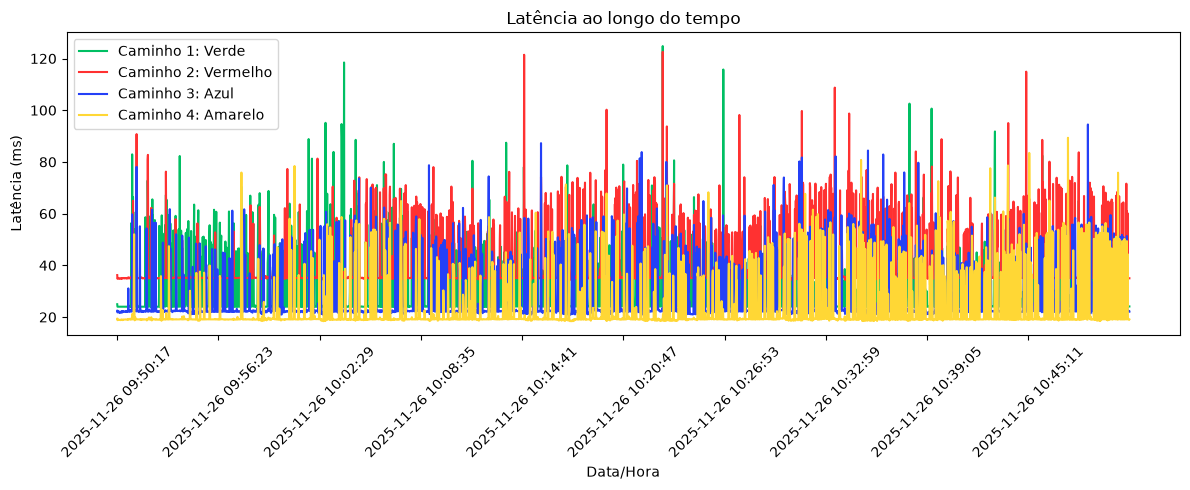

In [105]:
fig = plt.figure(figsize=(12, 5))

for pathId in pathIds:
    propriedades = rotas[pathId]
    nome = propriedades["nome"]
    cor = propriedades["cor"]

    plt.plot(datetimes, latencia_por_rota[:, pathId - 1], label=f'Caminho {pathId}: {nome}', color=cor, linewidth=1.5)

step = max(1, len(datetimes) // 10)  # mostra +- 10 datas no eixo
plt.xticks(datetimes[::step], rotation=45)

plt.legend()
plt.xlabel('Data/Hora')
plt.ylabel('Latência (ms)')
plt.title('Latência ao longo do tempo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Banda disponível por caminho

Carrega o CSV consolidado de banda disponível por caminho (`banda_rotas_h1_h6.csv`), gerado a partir dos relatórios finais de cada rota (`banda_rota_h1<r>_h6<r>.txt`) pela função `consolidarBanda` em `prototipo/helpers/parser_banda.py`, do mesmo jeito que `latencia_rotas_h1_h6.csv` é gerado para a latência.

In [106]:
historico_banda = pd.read_csv(f"{pasta_dataset}/{historico_banda_csv}")

banda_por_rota = historico_banda.iloc[:, 1:].values

banda_datetimes = historico_banda.iloc[:, 0].values
banda_datetimes_dt = pd.to_datetime(banda_datetimes)

print(banda_datetimes[:5], '\n')
print(banda_por_rota[:5])

<StringArray>
['2025-11-26 12:50:16', '2025-11-26 12:50:17', '2025-11-26 12:50:18',
 '2025-11-26 12:50:19', '2025-11-26 12:50:20']
Length: 5, dtype: str 

[[100.         100.         100.         100.        ]
 [ 99.99412537  99.99487305  99.99487305  99.99412537]
 [ 99.99700928  99.99700928  99.99700928  99.99700928]
 [ 99.99700928  99.99700928  99.99700928  99.99700928]
 [ 99.99700928  99.99700928  99.99700928  99.99700928]]


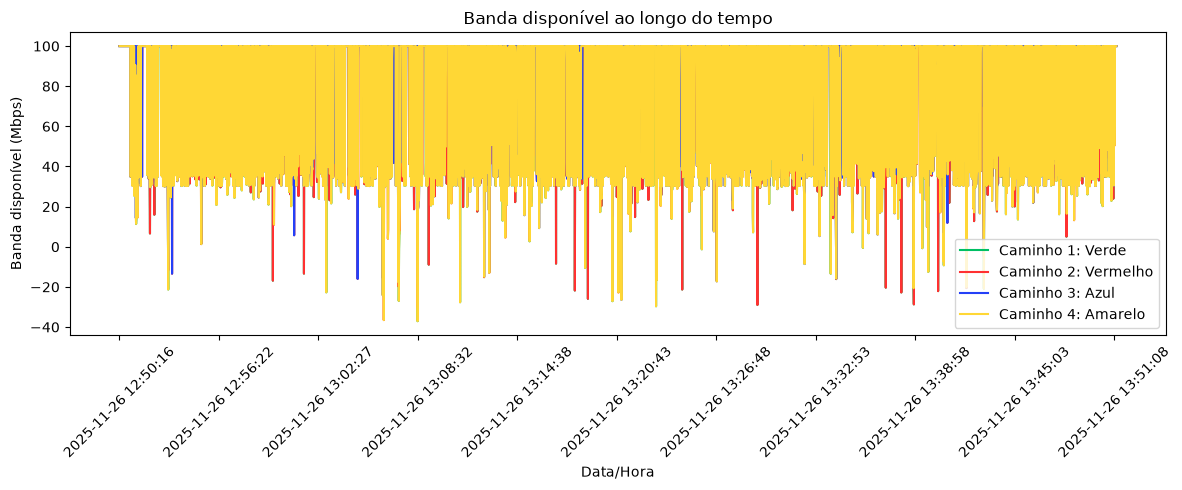

In [107]:
fig = plt.figure(figsize=(12, 5))

for pathId in pathIds:
    propriedades = rotas[pathId]
    nome = propriedades["nome"]
    cor = propriedades["cor"]

    plt.plot(banda_datetimes, banda_por_rota[:, pathId - 1], label=f'Caminho {pathId}: {nome}', color=cor, linewidth=1.5)

step = max(1, len(banda_datetimes) // 10)  # mostra +- 10 datas no eixo
plt.xticks(banda_datetimes[::step], rotation=45)

# Desativa a notação de offset do matplotlib (ex.: "+9.999e1"), que em datasets com
# pouca variação (ex: D1, banda quase toda entre 99.99 e 100 Mbps) deixava o eixo Y
# confuso. Mostra os valores reais diretamente, mantendo o zoom automático nos dados.
plt.ticklabel_format(axis='y', style='plain', useOffset=False)

plt.legend()
plt.xlabel('Data/Hora')
plt.ylabel('Banda disponível (Mbps)')
plt.title('Banda disponível ao longo do tempo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Interpolação da banda para os timestamps da latência

A banda e a latência são coletadas em processos separados, então seus timestamps não coincidem exatamente segundo a segundo. Para poder usar as duas em conjunto (ex.: como features do mesmo modelo), a banda disponível de cada caminho é interpolada nos timestamps exatos da latência (`datetimes_dt`), por interpolação temporal (`interpolate(method='time')`).

In [ ]:
banda_indexada = historico_banda.copy()
banda_indexada[banda_indexada.columns[0]] = pd.to_datetime(banda_indexada[banda_indexada.columns[0]])
banda_indexada = banda_indexada.set_index(banda_indexada.columns[0])

# Une os timestamps da banda com os da latência, interpola no tempo e depois
# mantém só os timestamps da latência, alinhando as duas séries
indice_uniao = banda_indexada.index.union(datetimes_dt)
banda_interpolada = (
    banda_indexada
    .reindex(indice_uniao)
    .sort_index()
    .interpolate(method='time', limit_direction='both')
    .reindex(datetimes_dt)
)

banda_por_rota_interp = banda_interpolada.values

print(f"Timestamps latência: {len(datetimes_dt)} | Timestamps banda original: {len(banda_datetimes_dt)}")
print(f"NaNs após interpolação: {np.isnan(banda_por_rota_interp).sum()}")
print(banda_por_rota_interp[:5])

# Execução do Pipeline

1.   Separação dos dados entre treino e teste (80% : 20%)
2.   Validação cruzada dos modelos com o conjunto de treino, com estratificação (não salva estados do treinamento)
3.   Treinamento dos modelos com o conjunto de treino
4.   Teste dos modelos com o conjunto de teste
5.   Comparação de desempenho entre treino (validação cruzada) e teste



In [ ]:
rotulos_dataset = np.unique(y).tolist()
binaryClassification = len(rotulos_dataset) <= 2

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=1234,
                                                    shuffle=True, stratify=None)
print(f"Total de amostras: {len(y)}\n")

print(f"Classes únicas:\t\t{rotulos_dataset}")
print(f'Classes em y_train:\t{np.unique(y_train)}')
print(f'Classes em y_test:\t{np.unique(y_test)}')

print("\nDistribuição das classes:")
print(pd.Series(y).value_counts())

In [ ]:
print(len(y_train), len(y_test), len(y_train) + len(y_test))

In [ ]:
resultados_cv = model_cross_validation(X_train, y_train, pipelines, folds=5, binary_classification=binaryClassification)

In [ ]:
trained_pipelines = model_train(X_train, y_train, pipelines)

In [ ]:
test_results = evaluate_on_test(
    X_test, 
    y_test, 
    trained_pipelines, 
    rotulos_dataset, 
    binary_classification=binaryClassification, 
    result_path=f'{pasta_resultados}'
)

In [ ]:
compare_train_test_performance(resultados_cv, test_results, result_path=f'{pasta_resultados}')

# Testes manuais após o treinamento

Obter cortes dos dados em momentos diferentes, para analisar como o modelo generalizou os diferentes padrões da rede ao longo do tempo.

In [ ]:
historico_latencias_novo = pd.read_csv(f"nova_latencia/60min_streaming_simultaneo/latencia_rotas_h1_h6.csv")
rotulos_novo = np.loadtxt(f"nova_latencia/60min_streaming_simultaneo/labels_h1_h6.txt", comments='#', dtype=int)

different_datetimes = historico_latencias_novo.iloc[:, 0].values
different_datetimes_dt = pd.to_datetime(different_datetimes)

different_temporal_features = np.column_stack([
    different_datetimes_dt.hour,           # Hora do dia (0-23)
    different_datetimes_dt.minute,         # Minuto (0-59)
    different_datetimes_dt.second,         # Segundo (0-59)
    # datetimes_dt.dayofweek,    # Dia da semana (0=Segunda, 6=Domingo) - irrelevante para o conjunto de dados atual
    different_datetimes_dt.day,            # Dia do mês (1-31)
    different_datetimes_dt.month,          # Mês (1-12)
    different_datetimes_dt.year            # Ano
])

different_routes_latency = historico_latencias_novo.iloc[:, 1:].values

X_different = np.hstack([different_temporal_features, different_routes_latency])
y_different = rotulos_novo

pathIds = [1, 2, 3, 4]
n_classes = len(pathIds)
binaryClassification = n_classes <= 2


fig = plt.figure(figsize=(12, 5))

for i in range(n_classes):
    pathId = i + 1

    propriedades = rotas[pathId]
    nome = propriedades["nome"]
    cor = propriedades["cor"]

    plt.plot(different_datetimes, different_routes_latency[:, i], label=f'Caminho {pathId}: {nome}', color=cor, linewidth=1.5)

step = max(1, len(different_datetimes) // 10)  # mostra +- 10 datas no eixo
plt.xticks(different_datetimes[::step], rotation=45)

plt.legend()
plt.xlabel('Data/Hora')
plt.ylabel('Latência (ms)')
plt.title('Latência ao longo do tempo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

test_results = evaluate_on_test(X_different, y_different, trained_pipelines, pathIds, binary_classification=binaryClassification, result_path=f'testes/antiga2nova/4/results')

## Outros testes

In [ ]:
begin = 0
end = 800

fraction_datetimes = datetimes[begin:end]
fraction_datetimes_dt = datetimes_dt[begin:end]
fraction_temporal_features = temporal_features[begin:end]
fraction_routes_latency = historico_latencias[begin:end]
fraction_routes_label = rotas[begin:end]

X_fraction = np.hstack([fraction_temporal_features, fraction_routes_latency])
y_fraction = fraction_routes_label

pathIds = np.unique(y)
n_classes = len(historico_latencias[0])

fig = plt.figure(figsize=(12, 5))

for i in range(n_classes):
    pathId = i + 1

    propriedades = rotas[pathId]
    nome = propriedades["nome"]
    cor = propriedades["cor"]

    plt.plot(fraction_datetimes, fraction_routes_latency[:, i], label=f'Caminho {pathId}: {nome}', color=cor, linewidth=1.5)

step = max(1, len(fraction_datetimes) // 10)  # mostra +- 10 datas no eixo
plt.xticks(fraction_datetimes[::step], rotation=45)

plt.legend()
plt.xlabel('Data/Hora')
plt.ylabel('Latência (ms)')
plt.title('Latência ao longo do tempo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

test_results = evaluate_on_test(X_fraction, y_fraction, trained_pipelines, rotulos_dataset, binary_classification=binaryClassification, result_path=f'{pasta_resultados}')

In [ ]:
begin = 1001
end = 2001

fraction_datetimes = datetimes[begin:end]
fraction_datetimes_dt = datetimes_dt[begin:end]
fraction_temporal_features = temporal_features[begin:end]
fraction_routes_latency = routes_latency[begin:end]
fraction_routes_label = routes_label[begin:end]

X_fraction = np.hstack([fraction_temporal_features, fraction_routes_latency])
y_fraction = fraction_routes_label

print(np.unique(y_fraction))

pathIds = np.unique(y)
n_classes = len(routes_latency[0])

fig = plt.figure(figsize=(12, 5))

for i in range(n_classes):
    pathId = i + 1

    propriedades = routes[pathId]
    nome = propriedades["nome"]
    cor = propriedades["cor"]

    plt.plot(fraction_datetimes, fraction_routes_latency[:, i], label=f'Caminho {pathId}: {nome}', color=cor, linewidth=1.5)

step = max(1, len(fraction_datetimes) // 10)  # mostra +- 10 datas no eixo
plt.xticks(fraction_datetimes[::step], rotation=45)

plt.legend()
plt.xlabel('Data/Hora')
plt.ylabel('Latência (ms)')
plt.title('Latência ao longo do tempo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

test_results = evaluate_on_test(X_fraction, y_fraction, trained_pipelines, class_labels, binary_classification=binaryClassification, result_path=f'{data_path}/results')

# Reprodução da Tabela 2 do artigo: generalização cross-dataset (latência vs. banda)

Este bloco reproduz o "Cenário 2" do artigo (treino em D1 e teste em D2/D3/D4 e D2b/D3b/D4b),
mas comparando duas versões de `X`:

- **`X` com latência** (igual ao artigo): `temporal_features + latência por rota`.
- **`X` com banda** (proxy alternativo): `temporal_features + banda por rota` (`banda_rotas_h1_h6.csv`).

Em ambos os casos, `y` continua vindo de `rotulos_h1_h6.txt` (definido como
`argmin(latência)` no instante). O objetivo é verificar se treinar com banda em vez
de latência muda a capacidade de generalização entre cenários de tráfego distintos,
respondendo à pergunta "dá pra generalizar sem retreino usando banda?" de forma
empírica, e não apenas especulativa.

**Importante**: este bloco treina seus próprios modelos (independentes de
`trained_pipelines` das seções anteriores), sempre a partir do dataset **D1**, para
garantir que o experimento seja reprodutível independentemente do que foi configurado
nas células de cima.


In [8]:
def carregar_X_y(dataset, pasta_raiz='datasets', metrica='latencia'):
    """Carrega X (temporal_features + metrica por rota) e y (rotulos) de um dataset.

    metrica: 'latencia' -> usa latencia_rotas_h1_h6.csv (igual ao artigo)
             'banda'     -> usa banda_rotas_h1_h6.csv (proxy alternativo)
    y sempre vem de rotulos_h1_h6.txt (definido como argmin(latencia) no instante),
    igual nos dois casos — só X muda.
    """
    pasta = f"{pasta_raiz}/{dataset}"
    arquivo_csv = 'latencia_rotas_h1_h6.csv' if metrica == 'latencia' else 'banda_rotas_h1_h6.csv'

    historico = pd.read_csv(f"{pasta}/{arquivo_csv}")
    rotulos_ds = np.loadtxt(f"{pasta}/rotulos_h1_h6.txt", comments='#', dtype=int)

    valores_por_rota = historico.iloc[:, 1:].values
    datetimes_ds = pd.to_datetime(historico.iloc[:, 0].values)

    temporal = np.column_stack([
        datetimes_ds.hour,
        datetimes_ds.minute,
        datetimes_ds.second,
        datetimes_ds.day,
        datetimes_ds.month,
        datetimes_ds.year,
    ])

    X_ds = np.hstack([temporal, valores_por_rota])
    y_ds = rotulos_ds

    # Datasets podem ter tamanhos ligeiramente diferentes entre X e y (ex.: 1
    # instante a mais/menos por causa de bordas de alinhamento entre latência e
    # banda) — trunca ao menor tamanho comum em vez de falhar, avisando quando
    # a diferença for maior que um punhado de linhas (o que indicaria um
    # problema real de desalinhamento, não apenas borda)
    if len(X_ds) != len(y_ds):
        diferenca = abs(len(X_ds) - len(y_ds))
        if diferenca > 5:
            raise ValueError(
                f"{dataset}/{metrica}: X tem {len(X_ds)} linhas, y tem {len(y_ds)} "
                f"(diferença de {diferenca}, maior que o esperado por borda de alinhamento)"
            )
        print(f"[{dataset}/{metrica}] truncando {diferenca} linha(s) de borda: "
              f"X={len(X_ds)}, y={len(y_ds)}")
        tamanho_comum = min(len(X_ds), len(y_ds))
        X_ds = X_ds[:tamanho_comum]
        y_ds = y_ds[:tamanho_comum]

    # Algumas leituras de banda/latência têm falhas pontuais (NaN) — descarta a
    # linha inteira (todas as rotas daquele instante) em vez de imputar valores,
    # para não introduzir viés artificial nos poucos pontos afetados
    linhas_validas = ~np.isnan(X_ds).any(axis=1)
    if not linhas_validas.all():
        descartadas = (~linhas_validas).sum()
        print(f"[{dataset}/{metrica}] descartando {descartadas}/{len(X_ds)} linha(s) com NaN")
    X_ds = X_ds[linhas_validas]
    y_ds = y_ds[linhas_validas]

    return X_ds, y_ds


In [4]:
def experimento_cross_dataset(dataset_treino, datasets_teste, metrica, pasta_raiz='datasets'):
    """Treina os 7 modelos clássicos em `dataset_treino` e testa em cada um de
    `datasets_teste`, usando `metrica` ('latencia' ou 'banda') como feature de rota.

    Retorna um DataFrame long: uma linha por (modelo, dataset_teste), com a
    acurácia — no mesmo espírito da Tabela 2 do artigo, mas parametrizado pela
    métrica usada como X.
    """
    X_treino, y_treino = carregar_X_y(dataset_treino, pasta_raiz, metrica)

    modelos_locais = {
        'LogisticRegression': LogisticRegression(max_iter=1000),
        'KNeighbors': KNeighborsClassifier(),
        'SVC': svm.SVC(probability=True),
        'DecisionTree': tree.DecisionTreeClassifier(),
        'ExtraTrees': ExtraTreesClassifier(),
        'RandomForest': RandomForestClassifier(),
        'GaussianNB': GaussianNB(),
    }

    for modelo in modelos_locais.values():
        modelo.fit(X_treino, y_treino)

    linhas = []
    for dataset_teste in datasets_teste:
        X_teste, y_teste = carregar_X_y(dataset_teste, pasta_raiz, metrica)
        for nome_modelo, modelo in modelos_locais.items():
            try:
                y_pred = modelo.predict(X_teste)
                acc = accuracy_score(y_teste, y_pred)
            except Exception as e:
                acc = np.nan
                print(f"[{metrica}] {nome_modelo} em {dataset_teste}: ERRO {e}")
            linhas.append({
                'Metrica_X': metrica,
                'Treino': dataset_treino,
                'Teste': dataset_teste,
                'Modelo': nome_modelo,
                'Acuracia': acc,
            })

    return pd.DataFrame(linhas)


In [9]:
resultados_cross = []

cenarios_teste = {
    'latencias_originais': ['D2', 'D3', 'D4'],
    'latencias_modificadas': ['D2b', 'D3b', 'D4b'],
}

for nome_cenario, datasets_teste in cenarios_teste.items():
    for metrica in ['latencia', 'banda']:
        r = experimento_cross_dataset('D1', datasets_teste, metrica)
        r.insert(0, 'Cenario', nome_cenario)
        resultados_cross.append(r)

resultados_cross_df = pd.concat(resultados_cross, ignore_index=True)
resultados_cross_df


[D1/banda] descartando 3/3599 linha(s) com NaN
[D2/banda] truncando 1 linha(s) de borda: X=3659, y=3660
[D2/banda] descartando 1/3659 linha(s) com NaN
[D3/banda] truncando 2 linha(s) de borda: X=3661, y=3663
[D4/banda] truncando 1 linha(s) de borda: X=3850, y=3851
[D4/banda] descartando 1/3850 linha(s) com NaN
[D1/banda] descartando 3/3599 linha(s) com NaN
[D2b/banda] truncando 5 linha(s) de borda: X=3645, y=3650
[D3b/banda] truncando 1 linha(s) de borda: X=3657, y=3658
[D3b/banda] descartando 2/3657 linha(s) com NaN
[D4b/banda] truncando 3 linha(s) de borda: X=3767, y=3770
[D4b/banda] descartando 1/3767 linha(s) com NaN


,Cenario,Metrica_X,Treino,Teste,Modelo,Acuracia
0,latencias_originais,latencia,D1,D2,LogisticRegression,0.777869
1,latencias_originais,latencia,D1,D2,KNeighbors,0.833607
2,latencias_originais,latencia,D1,D2,SVC,0.833607
3,latencias_originais,latencia,D1,D2,DecisionTree,0.749454
4,latencias_originais,latencia,D1,D2,ExtraTrees,0.858197
...,...,...,...,...,...,...
79,latencias_modificadas,banda,D1,D4b,SVC,0.002655
80,latencias_modificadas,banda,D1,D4b,DecisionTree,0.002921
81,latencias_modificadas,banda,D1,D4b,ExtraTrees,0.002655
82,latencias_modificadas,banda,D1,D4b,RandomForest,0.002655


In [10]:
# Resumo: acurácia média por (Cenário, Métrica_X, Modelo), agregando os datasets
# de teste de cada cenário — comparável à queda de desempenho relatada na Tabela 2
resumo_cross = (
    resultados_cross_df
    .groupby(['Cenario', 'Metrica_X', 'Modelo'])['Acuracia']
    .mean()
    .unstack('Metrica_X')
    .rename(columns={'latencia': 'Acc_media_com_latencia', 'banda': 'Acc_media_com_banda'})
    .sort_values(['Cenario', 'Acc_media_com_latencia'], ascending=[True, False])
)

resumo_cross['Diferenca_banda_menos_latencia'] = (
    resumo_cross['Acc_media_com_banda'] - resumo_cross['Acc_media_com_latencia']
)

resumo_cross.round(4)


Metrica_X                                 Acc_media_com_banda  \
Cenario               Modelo                                    
latencias_modificadas LogisticRegression               0.0014   
                      DecisionTree                     0.0019   
                      ExtraTrees                       0.0014   
                      RandomForest                     0.0014   
                      GaussianNB                       0.0014   
                      KNeighbors                       0.0014   
                      SVC                              0.0014   
latencias_originais   ExtraTrees                       0.6202   
                      RandomForest                     0.6202   
                      LogisticRegression               0.6202   
                      DecisionTree                     0.6200   
                      GaussianNB                       0.6202   
                      KNeighbors                       0.6202   
                      SVC                              0.6202   

Metrica_X                                 Acc_media_com_latencia  \
Cenario               Modelo                                       
latencias_modificadas LogisticRegression                  0.1366   
                      DecisionTree                        0.0863   
                      ExtraTrees                          0.0857   
                      RandomForest                        0.0405   
                      GaussianNB                          0.0014   
                      KNeighbors                          0.0014   
                      SVC                                 0.0014   
latencias_originais   ExtraTrees                          0.7604   
                      RandomForest                        0.7603   
                      LogisticRegression                  0.7538   
                      DecisionTree                        0.6551   
                      GaussianNB                          0.6203   
                      KNeighbors                          0.6203   
                      SVC                                 0.6203   

Metrica_X                                 Diferenca_banda_menos_latencia  
Cenario               Modelo                                              
latencias_modificadas LogisticRegression                         -0.1351  
                      DecisionTree                               -0.0844  
                      ExtraTrees                                 -0.0843  
                      RandomForest                               -0.0390  
                      GaussianNB                                  0.0000  
                      KNeighbors                                  0.0000  
                      SVC                                         0.0000  
latencias_originais   ExtraTrees                                 -0.1402  
                      RandomForest                               -0.1401  
                      LogisticRegression                         -0.1336  
                      DecisionTree                               -0.0351  
                      GaussianNB                                 -0.0001  
                      KNeighbors                                 -0.0001  
                      SVC                                        -0.0001

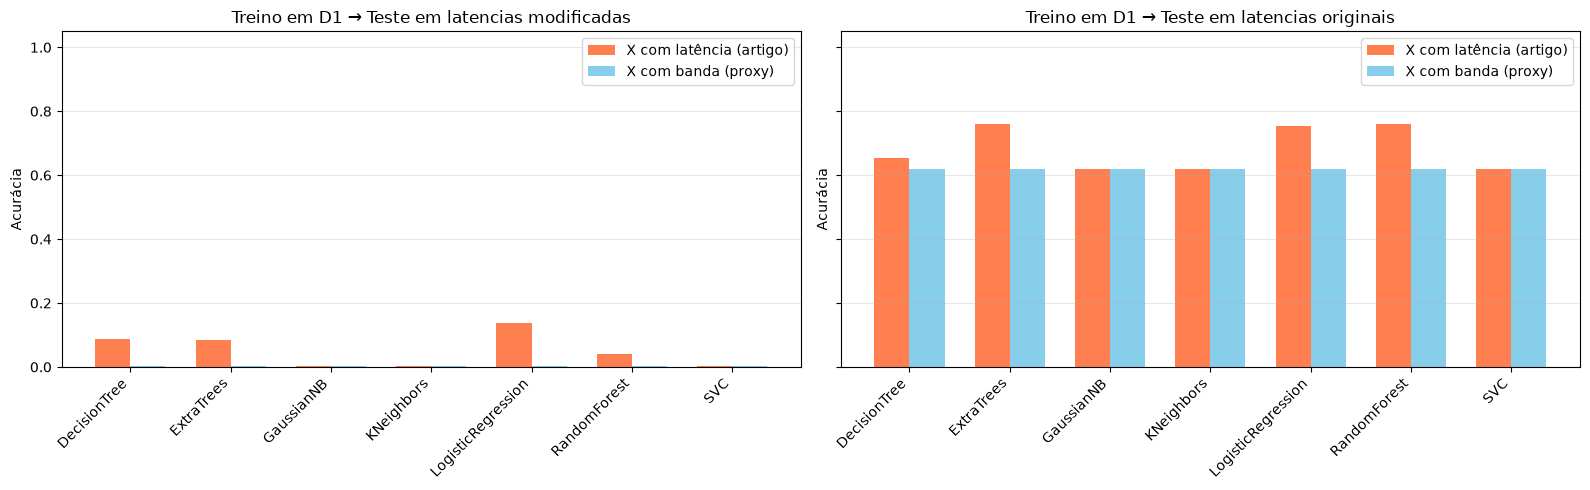

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, (nome_cenario, dados) in zip(axes, resultados_cross_df.groupby('Cenario')):
    pivot = dados.groupby(['Modelo', 'Metrica_X'])['Acuracia'].mean().unstack('Metrica_X')
    pivot = pivot.reindex(columns=['latencia', 'banda'])

    x = np.arange(len(pivot))
    width = 0.35

    ax.bar(x - width/2, pivot['latencia'], width, label='X com latência (artigo)', color='coral')
    ax.bar(x + width/2, pivot['banda'], width, label='X com banda (proxy)', color='skyblue')

    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=45, ha='right')
    ax.set_title(f'Treino em D1 → Teste em {nome_cenario.replace("_", " ")}')
    ax.set_ylabel('Acurácia')
    ax.set_ylim([0, 1.05])
    ax.grid(axis='y', alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig('resultados_am/generalizacao_latencia_vs_banda.png', dpi=300, bbox_inches='tight')
plt.show()


## Feature importance do experimento de generalização

Por que os modelos treinados em D1 colapsam ao testar em D2b/D3b/D4b (latências
modificadas)? Uma forma de investigar é olhar **quais features o RandomForest treinado
em D1 considerou mais importantes**, tanto por MDI (impureza média, calculada só com
dados de treino) quanto por **permutation importance calculada no dataset de teste**
(que reflete o que realmente contribui para acerto fora da distribuição de treino).

Colunas de `X`: `[hora, minuto, segundo, dia, mês, ano, rota_1, rota_2, rota_3, rota_4]`
(as 4 últimas são a métrica escolhida — latência ou banda — por caminho).

Comparar a MDI (calculada em D1) com a permutation importance calculada em D2b mostra
diretamente se o modelo está usando as colunas de rota (o que seria esperado/desejável)
ou se ele apenas decorou os padrões temporais de D1, que deixam de fazer sentido quando
a topologia de latências muda.


In [12]:
from sklearn.inspection import permutation_importance

NOMES_COLUNAS_X = ['hora', 'minuto', 'segundo', 'dia', 'mes', 'ano',
                    'rota_1', 'rota_2', 'rota_3', 'rota_4']


def importancia_cross_dataset(dataset_treino, dataset_teste, metrica, pasta_raiz='datasets',
                               random_state=42):
    """Treina um RandomForest em `dataset_treino` e retorna MDI (do treino) +
    permutation importance (avaliada em `dataset_teste`), lado a lado.

    Isso evidencia se o modelo se apoia nas colunas de rota (generalizável) ou
    nas colunas temporais (memorização do horário/dia de coleta de D1, que não
    tem nenhuma relação causal com qual rota é mais rápida).
    """
    X_treino, y_treino = carregar_X_y(dataset_treino, pasta_raiz, metrica)
    X_teste, y_teste = carregar_X_y(dataset_teste, pasta_raiz, metrica)

    modelo = RandomForestClassifier(random_state=random_state)
    modelo.fit(X_treino, y_treino)

    mdi = pd.Series(modelo.feature_importances_, index=NOMES_COLUNAS_X, name='MDI_treino')

    perm = permutation_importance(
        modelo, X_teste, y_teste, n_repeats=10, random_state=random_state, n_jobs=-1
    )
    permutacao = pd.Series(perm.importances_mean, index=NOMES_COLUNAS_X, name='Permutacao_teste')

    tabela = pd.concat([mdi, permutacao], axis=1)
    tabela['Metrica_X'] = metrica
    tabela['Treino'] = dataset_treino
    tabela['Teste'] = dataset_teste
    tabela['Acuracia_teste'] = accuracy_score(y_teste, modelo.predict(X_teste))

    return tabela.reset_index().rename(columns={'index': 'Feature'})


In [13]:
casos_importancia = [
    ('D1', 'D2', 'latencia'),
    ('D1', 'D2b', 'latencia'),
    ('D1', 'D2', 'banda'),
    ('D1', 'D2b', 'banda'),
]

tabelas_importancia = [
    importancia_cross_dataset(treino, teste, metrica)
    for treino, teste, metrica in casos_importancia
]

importancia_df = pd.concat(tabelas_importancia, ignore_index=True)
importancia_df.round(4)


[D1/banda] descartando 3/3599 linha(s) com NaN
[D2/banda] truncando 1 linha(s) de borda: X=3659, y=3660
[D2/banda] descartando 1/3659 linha(s) com NaN
[D1/banda] descartando 3/3599 linha(s) com NaN
[D2b/banda] truncando 5 linha(s) de borda: X=3645, y=3650


,Feature,MDI_treino,Permutacao_teste,Metrica_X,Treino,Teste,Acuracia_teste
0,hora,0.0000,0.0000,latencia,D1,D2,0.8481
1,minuto,0.0056,-0.0010,latencia,D1,D2,0.8481
2,segundo,0.0008,-0.0022,latencia,D1,D2,0.8481
3,dia,0.0000,0.0000,latencia,D1,D2,0.8481
4,mes,0.0000,0.0000,latencia,D1,D2,0.8481
5,ano,0.0000,0.0000,latencia,D1,D2,0.8481
6,rota_1,0.0328,-0.0004,latencia,D1,D2,0.8481
7,rota_2,0.5003,0.0053,latencia,D1,D2,0.8481
8,rota_3,0.0001,-0.0008,latencia,D1,D2,0.8481
9,rota_4,0.4604,0.0215,latencia,D1,D2,0.8481


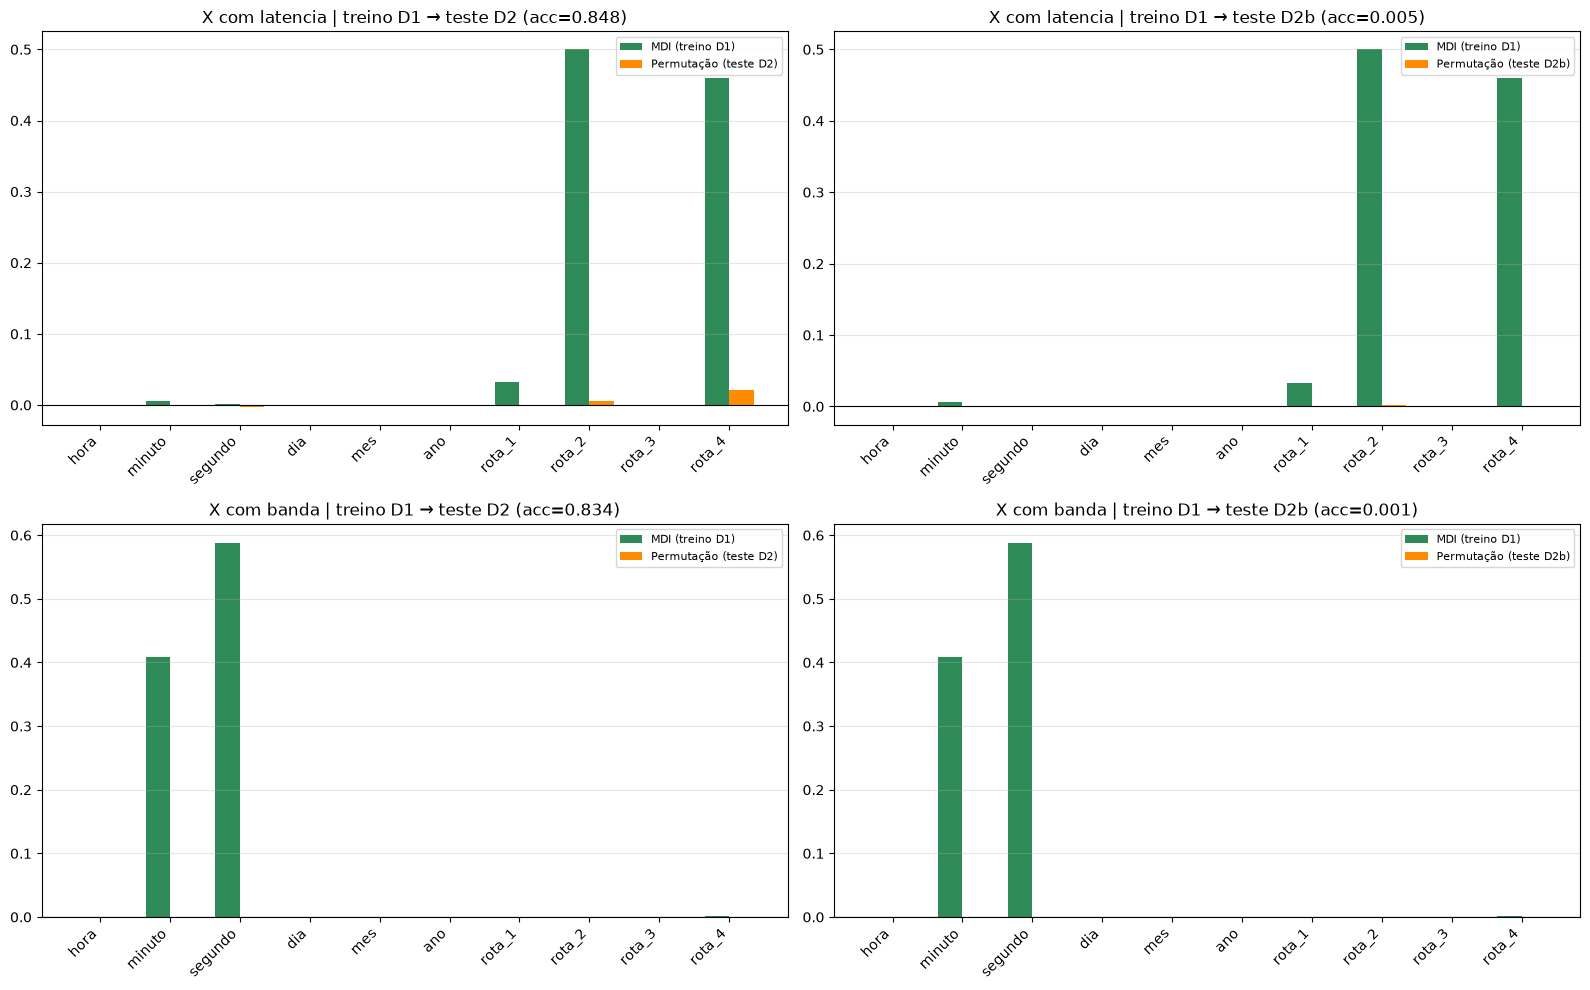

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, (treino, teste, metrica) in zip(axes.ravel(), casos_importancia):
    subset = importancia_df[
        (importancia_df.Treino == treino) &
        (importancia_df.Teste == teste) &
        (importancia_df.Metrica_X == metrica)
    ].set_index('Feature')

    x = np.arange(len(subset))
    width = 0.35

    ax.bar(x - width/2, subset['MDI_treino'], width, label=f'MDI (treino {treino})', color='seagreen')
    ax.bar(x + width/2, subset['Permutacao_teste'], width, label=f'Permutação (teste {teste})', color='darkorange')

    acc = subset['Acuracia_teste'].iloc[0]
    ax.set_xticks(x)
    ax.set_xticklabels(subset.index, rotation=45, ha='right')
    ax.set_title(f'X com {metrica} | treino {treino} → teste {teste} (acc={acc:.3f})')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('resultados_am/importancia_generalizacao_latencia_vs_banda.png', dpi=300, bbox_inches='tight')
plt.show()


# Pipeline de latência com protocolo preditivo

As seções anteriores avaliam uma tarefa **contemporânea**: `X` e `y` vêm do mesmo
instante e o split 80/20 usa `shuffle=True`. Como a série é fortemente
autocorrelacionada, o embaralhamento coloca segundos vizinhos (quase idênticos)
em treino e teste ao mesmo tempo, o que infla a acurácia sem que o modelo tenha
demonstrado capacidade preditiva.

Esta seção **acrescenta** um segundo protocolo para o mesmo pipeline de latência,
reaproveitando os helpers de `protocolo_temporal.py`, na raiz do projeto. Esse
módulo é o ponto comum entre as duas análises: a de importância de features, na
feature store, chega nele através de `feature_store/pipeline.py`, que o
reexporta, e este notebook o importa direto, sem passar pela feature store.

- **`pt.deslocar_alvo(largo, H)`** — troca o alvo por `melhor_rota(t + H)`,
  mantendo `X` com informação apenas até `t`. O deslocamento é feito por
  casamento explícito de `ts_epoch + H` (não por `shift(-H)` posicional), e o
  rótulo contemporâneo é preservado em `alvo_atual`.
- **`pt.split_temporal(largo, fracao_treino, lacuna_s)`** — corte cronológico
  por dataset, com uma lacuna de `H` segundos entre treino e teste para que
  nenhum alvo de treino (observado em `t + H`) caia dentro do bloco de teste.
- **`pt.preparar_treino_teste(largo, H)`** — a composição das duas, que é o que
  os dois notebooks realmente chamam.
- **`pt.largo_de_csv(csv, rotulos)`** — monta o quadro de entrada a partir de um
  CSV consolidado por rota. Como só assume "timestamp na primeira coluna, uma
  coluna por rota nas demais", serve tanto para `latencia_rotas_h1_h6.csv` quanto
  para `banda_rotas_h1_h6.csv`.

O contrato entre as duas pontas é um quadro largo com `dataset_id`, `ts_epoch`,
uma coluna por rota e `melhor_rota`. Na feature store ele sai de
`pipeline.construir_wide`; aqui, de `pt.largo_de_csv`.

O que muda em relação às seções acima, e por quê:

| item | seções anteriores | esta seção |
|---|---|---|
| alvo | `melhor_rota(t)` | `melhor_rota(t + H)` via `fs.deslocar_alvo` |
| split | `train_test_split(shuffle=True)` | `fs.split_temporal` com lacuna de `H` s |
| validação cruzada | `StratifiedKFold(shuffle=True)` | `TimeSeriesSplit` (treina no passado, valida no futuro) |
| features | `temporal_features` + latência por rota | **apenas** latência por rota |
| pré-processamento | nenhum | `StandardScaler` no pipeline |
| baselines | nenhum | persistência (`alvo_atual`) e classe majoritária |

As `temporal_features` (hora, minuto, segundo, dia, mês, ano) ficam de fora de
propósito: sob split cronológico elas identificam o bloco de teste, e o modelo
aprende o relógio em vez da rede. O rótulo continua sendo o **original** de
`rotulos_h1_h6.txt`, sem recálculo, para que a comparação isole o protocolo.

Nada acima é alterado: variáveis novas usam o sufixo `_pred`, os modelos vão
para `models_preditivo/` e os resultados para
`resultados_am/CenarioPreditivo_{DATASET}_H{H}/`.

In [106]:
# Protocolo de avaliação temporal compartilhado. A raiz do projeto é localizada
#   pelos diretórios que só existem nela, para o notebook funcionar tanto do
#   root quanto de uma subpasta.
import sys
from pathlib import Path

from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler


def raiz_do_projeto(marcadores=('prototipo', 'feature_store', 'datasets')):
    for candidato in [Path.cwd(), *Path.cwd().parents]:
        if all((candidato / marcador).is_dir() for marcador in marcadores):
            return candidato
    raise RuntimeError(
        f'raiz do projeto não encontrada a partir de {Path.cwd()}. '
        f'Esperado um diretório contendo {marcadores}.'
    )


RAIZ_PRED = raiz_do_projeto()
if str(RAIZ_PRED) not in sys.path:
    sys.path.insert(0, str(RAIZ_PRED))

import protocolo_temporal as pt

print(f'raiz do projeto : {RAIZ_PRED}')
print(f'módulo comum    : {pt.__file__}')
print(f'deslocar_alvo   : {pt.deslocar_alvo.__module__}.deslocar_alvo')
print(f'split_temporal  : {pt.split_temporal.__module__}.split_temporal')

raiz do projeto : /home/beatrizam/Documents/beatriz/path-aware-datasets
módulo comum    : /home/beatrizam/Documents/beatriz/path-aware-datasets/protocolo_temporal.py
deslocar_alvo   : protocolo_temporal.deslocar_alvo
split_temporal  : protocolo_temporal.split_temporal


In [107]:
# Datasets com o par completo (latencia_rotas_h1_h6.csv + rotulos_h1_h6.txt) e
#   as 4 rotas. D3a/D4a ficam fora: têm 2 rotas e outros nomes de arquivo.
DATASETS_PRED = ['D1', 'D1b', 'D2', 'D2b', 'D3', 'D3b', 'D4', 'D4b']

# Horizontes de previsão em segundos. H = 0 reproduz a tarefa contemporânea das
#   seções anteriores, mas já com split cronológico: a diferença entre essa
#   linha e a acurácia da seção "Execução do Pipeline" isola quanto vinha do
#   shuffle e quanto vinha da informação nas features.
HORIZONTES_PRED = [0, 1, 5, 15, 30, 60]

# Horizonte de referência, usado nas tabelas por dataset e nos artefatos
H_PRED = 30

FRACAO_TREINO_PRED = 0.8
RANDOM_STATE_PRED = 1234
CV_FOLDS_PRED = 5

# Reaproveita a configuração da seção "Carregamento do dataset" quando ela já
#   foi executada; caso contrário usa os mesmos padrões dela.
DATASET_PRED = globals().get('DATASET', 'D2')
PASTA_DATASETS_PRED = RAIZ_PRED / globals().get('DATASET_FOLDER', 'datasets')
PASTA_RESULTADOS_RAIZ_PRED = RAIZ_PRED / globals().get('RESULTS_FOLDER', 'resultados_am')

# Prefixo das colunas de feature, na convenção '<metrica>__<rota>' usada pelos
#   dois caminhos. Trocar por pt.PREFIXO_POR_METRICA['banda'] repete a análise
#   com banda_rotas_h1_h6.csv no lugar da latência.
PREFIXO_PRED = pt.PREFIXO_POR_METRICA['latencia']

PASTA_MODELOS_PRED = RAIZ_PRED / 'models_preditivo'
pasta_resultados_pred = PASTA_RESULTADOS_RAIZ_PRED / f'CenarioPreditivo_{DATASET_PRED}_H{H_PRED}'
pasta_resultados_pred.mkdir(parents=True, exist_ok=True)

print(f'dataset     : {DATASET_PRED}')
print(f'horizontes  : {HORIZONTES_PRED} (referência: H={H_PRED}s)')
print(f'resultados  : {pasta_resultados_pred}')

dataset     : D3
horizontes  : [0, 1, 5, 15, 30, 60] (referência: H=30s)
resultados  : /home/beatrizam/Documents/beatriz/path-aware-datasets/resultados_am/CenarioPreditivo_D3_H30


In [108]:
def construir_largo_latencia(dataset, pasta_raiz=None):
    """Quadro largo de um dataset, no contrato de protocolo_temporal.

    Só resolve os caminhos do dataset: a montagem em si é de pt.largo_de_csv,
    compartilhada com a análise da feature store. O rótulo vem de
    rotulos_h1_h6.txt sem recálculo, porque esta seção muda o protocolo de
    avaliação, não o alvo.
    """
    pasta = Path(pasta_raiz or PASTA_DATASETS_PRED) / dataset
    return pt.largo_de_csv(
        pasta / 'latencia_rotas_h1_h6.csv',
        pasta / 'rotulos_h1_h6.txt',
        grupo=dataset,
    )


def colunas_latencia(largo):
    """Colunas de feature do quadro, restritas à métrica desta seção."""
    return pt.colunas_de_feature(largo, prefixo=PREFIXO_PRED)


largo_pred = construir_largo_latencia(DATASET_PRED)

print(f'{DATASET_PRED}: {len(largo_pred)} instantes, '
      f'{len(colunas_latencia(largo_pred))} rotas')
print(f'classes presentes: {sorted(largo_pred.melhor_rota.unique().tolist())}')
largo_pred.head()

D3: 3663 instantes, 4 rotas
classes presentes: [1, 2, 3, 4]


,dataset_id,ts_epoch,latencia_ms__h11_h61,latencia_ms__h12_h62,latencia_ms__h13_h63,latencia_ms__h14_h64,melhor_rota
0,D3,1764172572,119.184448,133.420585,30.992741,28.750061,4
1,D3,1764172573,136.127184,146.374118,22.200000,19.651704,4
2,D3,1764172574,183.685759,193.931479,22.388689,19.611723,4
3,D3,1764172575,231.241615,241.491599,22.123103,19.500000,4
4,D3,1764172576,278.806023,289.041287,22.025452,19.250073,4


## Class distribution

Three views of the target for the reference horizon: the whole series, the
training block alone and the test block alone. Train and test do not add up to
the full count, because the `H`-second gap `split_temporal` leaves between the
blocks belongs to neither, and `deslocar_alvo` drops the rows whose `t + H` was
not observed.

Worth reading before any accuracy number. A scenario where one route is best in
virtually every instant (D1) has almost nothing to predict, so a high accuracy
only restates the imbalance. And when the dominant route differs between the two
blocks (D4), the majority-class baseline stops measuring the imbalance and starts
measuring the regime shift between the periods.

In [109]:
def class_distribution(largo, horizon_s=H_PRED, fraction=FRACAO_TREINO_PRED):
    """Target distribution over the whole series and over each chronological block.

    Rows are routes, columns are the absolute count and the share within each
    block. Applies the same protocol as the evaluation (deslocar_alvo followed by
    split_temporal), so the numbers describe exactly the blocks the models are
    trained and tested on.
    """
    frame, train, test = pt.preparar_treino_teste(largo, horizon_s, fracao_treino=fraction)
    target = frame['melhor_rota'].astype(int)
    routes = sorted(target.unique())

    blocks = {
        'full': target,
        'train': target[train.to_numpy()],
        'test': target[test.to_numpy()],
    }

    columns = {}
    for name, block in blocks.items():
        counts = block.value_counts().reindex(routes, fill_value=0)
        columns[f'{name}_n'] = counts
        columns[f'{name}_%'] = (counts / len(block) * 100).round(2) if len(block) else counts * 0.0

    table = pd.DataFrame(columns)
    table.index.name = 'route'

    totals = {}
    for name, block in blocks.items():
        totals[f'{name}_n'] = len(block)
        totals[f'{name}_%'] = 100.0 if len(block) else 0.0
    table.loc['total'] = pd.Series(totals)

    # Adding a row with .loc promotes the counts to float; bring them back to int
    for name in blocks:
        table[f'{name}_n'] = table[f'{name}_n'].astype(int)

    for name, block in blocks.items():
        if not len(block):
            print(f'{name:5s}: empty block')
            continue
        dominant = int(block.value_counts().idxmax())
        print(f'{name:5s}: {len(block):5d} instants | {block.nunique()} class(es) present | '
              f'dominant route {dominant} in {(block == dominant).mean():.2%} of them')

    return table


print(f'{DATASET_PRED}, H={H_PRED}s, train fraction {FRACAO_TREINO_PRED:.0%}')
distribution_pred = class_distribution(largo_pred)
distribution_pred

D3, H=30s, train fraction 80%
deslocar_alvo(H=30s): descartando 30/3663 linha(s) sem observacao em t+30s
full :  3633 instants | 4 class(es) present | dominant route 4 in 51.75% of them
train:  2907 instants | 4 class(es) present | dominant route 4 in 49.36% of them
test :   696 instants | 4 class(es) present | dominant route 4 in 61.64% of them


,full_n,full_%,train_n,train_%,test_n,test_%
route,,,,,,
1,332,9.14,264,9.08,65,9.34
2,48,1.32,30,1.03,17,2.44
3,1373,37.79,1178,40.52,185,26.58
4,1880,51.75,1435,49.36,429,61.64
total,3633,100.00,2907,100.00,696,100.00


In [110]:
def pipelines_preditivos(random_state=RANDOM_STATE_PRED):
    """Os mesmos 7 classificadores da seção "Ambiente de avaliação dos modelos",
    agora com StandardScaler no pipeline: KNN e SVC são sensíveis à escala, e as
    latências variam de poucos a centenas de milissegundos entre as rotas.

    Devolve instâncias novas a cada chamada, para que um horizonte não herde o
    estado treinado do horizonte anterior.
    """
    modelos = [
        ('LogisticRegression', LogisticRegression(max_iter=1000)),
        ('KNeighbors', KNeighborsClassifier()),
        ('SVC', svm.SVC(probability=True, random_state=random_state)),
        ('DecisionTree', tree.DecisionTreeClassifier(random_state=random_state)),
        ('ExtraTrees', ExtraTreesClassifier(random_state=random_state)),
        ('RandomForest', RandomForestClassifier(random_state=random_state)),
        ('GaussianNB', GaussianNB()),
    ]
    return {
        nome: Pipeline(steps=[('scaler', StandardScaler()), ('classifier', modelo)])
        for nome, modelo in modelos
    }


def validacao_cruzada_temporal(X_train, y_train, pipelines, folds=CV_FOLDS_PRED):
    """Validação cruzada com TimeSeriesSplit, dentro do bloco de treino.

    Cada dobra treina em um prefixo da série e valida no trecho imediatamente
    seguinte. Substitui model_cross_validation, cujo StratifiedKFold embaralha
    os instantes e reintroduz, dentro do treino, o vazamento que o split
    cronológico acabou de eliminar.

    Devolve um DataFrame com as mesmas colunas de model_cross_validation, para
    poder ser passado a compare_train_test_performance.
    """
    tscv = TimeSeriesSplit(n_splits=folds)
    linhas = []

    print('=' * 80)
    print(f'VALIDAÇÃO CRUZADA TEMPORAL NO TREINO (TimeSeriesSplit, {folds} dobras)')
    print('=' * 80)

    for nome_modelo, pipeline in pipelines.items():
        try:
            acuracias, precisoes, revocacoes, f1s = [], [], [], []

            for indices_treino, indices_validacao in tscv.split(X_train):
                modelo = clone(pipeline)
                modelo.fit(X_train[indices_treino], y_train[indices_treino])
                y_pred = modelo.predict(X_train[indices_validacao])
                y_real = y_train[indices_validacao]

                acuracias.append(accuracy_score(y_real, y_pred))
                precisoes.append(precision_score(y_real, y_pred, average='macro', zero_division=0))
                revocacoes.append(recall_score(y_real, y_pred, average='macro', zero_division=0))
                f1s.append(f1_score(y_real, y_pred, average='macro', zero_division=0))

            linhas.append({
                'Model': nome_modelo,
                'Acc_mean': f'{np.mean(acuracias):.4f}',
                'Acc_std': f'{np.std(acuracias):.4f}',
                'Precision': f'{np.mean(precisoes):.4f}',
                'Recall': f'{np.mean(revocacoes):.4f}',
                'F1-Score': f'{np.mean(f1s):.4f}',
            })

            print(f'{nome_modelo:20s} | Acc: {np.mean(acuracias):.4f} ± {np.std(acuracias):.4f}')

        except Exception as erro:
            print(f'{nome_modelo:20s} | ERRO: {erro}')
            linhas.append({
                'Model': nome_modelo, 'Acc_mean': 'ERRO', 'Acc_std': 'ERRO',
                'Precision': 'ERRO', 'Recall': 'ERRO', 'F1-Score': 'ERRO',
            })

    return pd.DataFrame(linhas)

In [111]:
def avaliar_preditivo_latencia(largo, horizonte_s, fracao_treino=FRACAO_TREINO_PRED,
                               salvar_modelos=False):
    """Treina e avalia a previsão de melhor_rota em t + horizonte_s.

    1. pt.deslocar_alvo  - y passa a ser melhor_rota(t + H); o rótulo de agora
                           fica em alvo_atual, para o baseline de persistência
    2. pt.split_temporal - primeiros `fracao_treino` instantes de cada dataset
                           para treino, últimos para teste, com lacuna de H s
    3. treino dos 7 modelos e avaliação no bloco de teste

    Os passos 1 e 2 vêm de pt.preparar_treino_teste. Com H = 0 o alvo não é
    deslocado (a tarefa fica contemporânea, mas já com corte cronológico) e
    alvo_atual recebe o próprio alvo, então a persistência dá 1.0 por
    construção: só as linhas com H > 0 comparam de fato contra ela.

    Dois baselines contextualizam a acurácia:
      persistência - prever que a melhor rota daqui a H segundos é a de agora;
                     é o que um controlador reativo faria sem modelo nenhum
      majoritária  - prever sempre a classe mais frequente do TREINO (estimar
                     essa classe no teste já seria vazamento)
    """
    quadro, treino, teste = pt.preparar_treino_teste(
        largo, horizonte_s, fracao_treino=fracao_treino
    )

    colunas_X = colunas_latencia(quadro)
    X = quadro[colunas_X].to_numpy(dtype=float)
    y = quadro['melhor_rota'].to_numpy(dtype=int)

    mascara_treino, mascara_teste = treino.to_numpy(), teste.to_numpy()
    X_treino, y_treino = X[mascara_treino], y[mascara_treino]
    X_teste, y_teste = X[mascara_teste], y[mascara_teste]

    pipelines_locais = pipelines_preditivos()
    treinados = {}
    linhas = []

    for nome_modelo, pipeline in pipelines_locais.items():
        pipeline.fit(X_treino, y_treino)
        treinados[nome_modelo] = pipeline

        if salvar_modelos:
            PASTA_MODELOS_PRED.mkdir(exist_ok=True)
            joblib.dump(pipeline, PASTA_MODELOS_PRED / f'{nome_modelo}_H{horizonte_s}.pkl')

        y_pred = pipeline.predict(X_teste)
        linhas.append({
            'Modelo': nome_modelo,
            'Acuracia': accuracy_score(y_teste, y_pred),
            'F1-macro': f1_score(y_teste, y_pred, average='macro', zero_division=0),
        })

    # Baselines medidos exatamente nas mesmas linhas de teste, para serem
    #   comparáveis com a acurácia dos modelos
    persistencia = float(
        (quadro.loc[teste, pt.COLUNA_ALVO_ATUAL].to_numpy(dtype=int) == y_teste).mean()
    )
    classe_majoritaria = int(pd.Series(y_treino).value_counts().idxmax())
    majoritaria = float((y_teste == classe_majoritaria).mean())

    return {
        'horizonte_s': horizonte_s,
        'resultados': pd.DataFrame(linhas),
        'persistencia': persistencia,
        'majoritaria': majoritaria,
        'classe_majoritaria': classe_majoritaria,
        'n_treino': len(X_treino),
        'n_teste': len(X_teste),
        'colunas_X': colunas_X,
        'classes': sorted(set(y_treino.tolist()) | set(y_teste.tolist())),
        'treinados': treinados,
        'X_treino': X_treino, 'y_treino': y_treino,
        'X_teste': X_teste, 'y_teste': y_teste,
    }

## Varredura de horizontes

Uma execução por horizonte, sempre no dataset configurado. A leitura importante
não é a acurácia absoluta, e sim a comparação de cada linha com a persistência:
se o modelo não supera "a melhor rota daqui a `H` segundos é a melhor rota de
agora", ele não está prevendo nada que um controlador reativo não obtivesse de
graça.

In [112]:
resultados_pred = {}

for H in HORIZONTES_PRED:
    resultados_pred[H] = avaliar_preditivo_latencia(largo_pred, H)
    r = resultados_pred[H]
    melhor = r['resultados'].sort_values('Acuracia', ascending=False).iloc[0]
    print(f"H={H:3d}s | treino={r['n_treino']:5d} teste={r['n_teste']:5d} | "
          f"melhor modelo: {melhor['Modelo']:18s} acc={melhor['Acuracia']:.4f} | "
          f"persistência={r['persistencia']:.4f} | majoritária={r['majoritaria']:.4f}")

H=  0s | treino= 2931 teste=  732 | melhor modelo: ExtraTrees         acc=0.9932 | persistência=1.0000 | majoritária=0.6093
deslocar_alvo(H=1s): descartando 1/3663 linha(s) sem observacao em t+1s
H=  1s | treino= 2930 teste=  731 | melhor modelo: RandomForest       acc=0.6580 | persistência=0.6238 | majoritária=0.6088
deslocar_alvo(H=5s): descartando 5/3663 linha(s) sem observacao em t+5s
H=  5s | treino= 2927 teste=  726 | melhor modelo: LogisticRegression acc=0.6129 | persistência=0.4477 | majoritária=0.6129
deslocar_alvo(H=15s): descartando 15/3663 linha(s) sem observacao em t+15s
H= 15s | treino= 2919 teste=  714 | melhor modelo: LogisticRegression acc=0.6162 | persistência=0.4356 | majoritária=0.6162
deslocar_alvo(H=30s): descartando 30/3663 linha(s) sem observacao em t+30s
H= 30s | treino= 2907 teste=  696 | melhor modelo: LogisticRegression acc=0.6164 | persistência=0.4411 | majoritária=0.6164
deslocar_alvo(H=60s): descartando 60/3663 linha(s) sem observacao em t+60s
H= 60s | tr

In [113]:
# Acurácia por modelo e por horizonte, com os dois baselines nas últimas linhas
tabela_pred = pd.concat(
    [r['resultados'].assign(Horizonte=H) for H, r in resultados_pred.items()],
    ignore_index=True
).pivot(index='Modelo', columns='Horizonte', values='Acuracia')

baselines_pred = pd.DataFrame(
    {
        'baseline: persistência': {H: r['persistencia'] for H, r in resultados_pred.items()},
        'baseline: classe majoritária': {H: r['majoritaria'] for H, r in resultados_pred.items()},
    }
).T
baselines_pred.columns.name = 'Horizonte'

tabela_pred_completa = pd.concat([tabela_pred, baselines_pred])

# Mean and sample standard deviation (ddof=1) across the predictive horizons
#   only. H = 0 is left out on purpose: there y and X come from the same instant,
#   so that column is a near-identity mapping rather than a forecast, and
#   averaging it in would inflate every row by the same artifact.
horizontes_preditivos = [h for h in tabela_pred_completa.columns if h > 0]
tabela_pred_completa['mean (H>0)'] = tabela_pred_completa[horizontes_preditivos].mean(axis=1)
tabela_pred_completa['std (H>0)'] = tabela_pred_completa[horizontes_preditivos].std(axis=1)

tabela_pred_completa.to_csv(pasta_resultados_pred / 'acuracia_por_horizonte.csv')

print(f'salvo em {pasta_resultados_pred / "acuracia_por_horizonte.csv"}')
tabela_pred_completa.round(4)

salvo em /home/beatrizam/Documents/beatriz/path-aware-datasets/resultados_am/CenarioPreditivo_D3_H30/acuracia_por_horizonte.csv


Horizonte,0,1,5,15,30,60,mean (H>0),std (H>0)
DecisionTree,0.9904,0.5554,0.4215,0.4384,0.4813,0.4000,0.4593,0.0615
ExtraTrees,0.9932,0.6539,0.5441,0.5350,0.5632,0.5333,0.5659,0.0506
GaussianNB,0.3689,0.1368,0.1171,0.1176,0.1135,0.1121,0.1194,0.0100
KNeighbors,0.9413,0.6047,0.4862,0.4902,0.5057,0.5212,0.5216,0.0484
LogisticRegression,0.8607,0.6129,0.6129,0.6162,0.6164,0.6136,0.6144,0.0018
RandomForest,0.9932,0.6580,0.5427,0.5602,0.5848,0.5606,0.5813,0.0454
SVC,0.8238,0.6293,0.6129,0.6162,0.6164,0.6136,0.6177,0.0067
baseline: persistência,1.0000,0.6238,0.4477,0.4356,0.4411,0.5167,0.4930,0.0802
baseline: classe majoritária,0.6093,0.6088,0.6129,0.6162,0.6164,0.6136,0.6136,0.0031


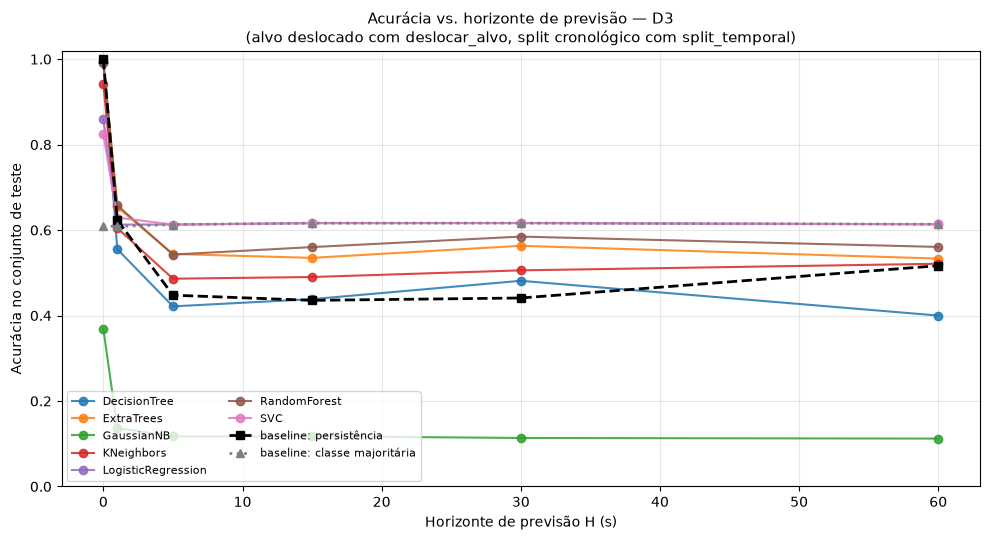

In [114]:
fig, ax = plt.subplots(figsize=(10, 5.5))

for modelo in tabela_pred.index:
    ax.plot(tabela_pred.columns, tabela_pred.loc[modelo], marker='o', alpha=0.85, label=modelo)

ax.plot(baselines_pred.columns, baselines_pred.loc['baseline: persistência'],
        marker='s', linestyle='--', color='black', linewidth=2, label='baseline: persistência')
ax.plot(baselines_pred.columns, baselines_pred.loc['baseline: classe majoritária'],
        marker='^', linestyle=':', color='gray', linewidth=2, label='baseline: classe majoritária')

ax.set_xlabel('Horizonte de previsão H (s)')
ax.set_ylabel('Acurácia no conjunto de teste')
ax.set_title(f'Acurácia vs. horizonte de previsão — {DATASET_PRED}\n'
             f'(alvo deslocado com deslocar_alvo, split cronológico com split_temporal)',
             fontsize=11)
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2, loc='lower left')

plt.tight_layout()
plt.savefig(pasta_resultados_pred / 'acuracia_por_horizonte.png', dpi=300, bbox_inches='tight')
plt.show()

## O mesmo protocolo em todos os datasets

Com `H` fixo no horizonte de referência, para ver onde o protocolo preditivo
ainda deixa margem sobre a persistência. Datasets com uma classe dominante
(`D1` e `D1b`, em que uma rota é a melhor em quase todos os instantes) tornam
os dois baselines altos e o ganho do modelo pequeno por construção — a leitura
útil está nos cenários com troca frequente de melhor rota.

In [115]:
linhas_por_dataset = []

for dataset in DATASETS_PRED:
    largo_ds = construir_largo_latencia(dataset)
    r = avaliar_preditivo_latencia(largo_ds, H_PRED)
    melhor = r['resultados'].sort_values('Acuracia', ascending=False).iloc[0]

    linhas_por_dataset.append({
        'Dataset': dataset,
        'Melhor modelo': melhor['Modelo'],
        'Acuracia': melhor['Acuracia'],
        'F1-macro': melhor['F1-macro'],
        'Persistencia': r['persistencia'],
        'Majoritaria': r['majoritaria'],
        'Ganho sobre persistencia': melhor['Acuracia'] - r['persistencia'],
        'Classes': len(r['classes']),
        'n treino': r['n_treino'],
        'n teste': r['n_teste'],
    })

pred_por_dataset = pd.DataFrame(linhas_por_dataset).set_index('Dataset')
pred_por_dataset.to_csv(pasta_resultados_pred / f'por_dataset_H{H_PRED}.csv')

print(f'H={H_PRED}s | split cronológico por dataset, lacuna de {H_PRED}s')
pred_por_dataset.round(4)

deslocar_alvo(H=30s): descartando 30/3599 linha(s) sem observacao em t+30s
deslocar_alvo(H=30s): descartando 30/3599 linha(s) sem observacao em t+30s
deslocar_alvo(H=30s): descartando 30/3660 linha(s) sem observacao em t+30s
deslocar_alvo(H=30s): descartando 30/3650 linha(s) sem observacao em t+30s
deslocar_alvo(H=30s): descartando 30/3663 linha(s) sem observacao em t+30s
deslocar_alvo(H=30s): descartando 30/3658 linha(s) sem observacao em t+30s
deslocar_alvo(H=30s): descartando 30/3851 linha(s) sem observacao em t+30s
deslocar_alvo(H=30s): descartando 30/3770 linha(s) sem observacao em t+30s
H=30s | split cronológico por dataset, lacuna de 30s


,Melhor modelo,Acuracia,F1-macro,Persistencia,Majoritaria,Ganho sobre persistencia,Classes,n treino,n teste
Dataset,,,,,,,,,
D1,LogisticRegression,1.0000,1.0000,1.0000,1.0000,0.0000,2,2856,683
D1b,LogisticRegression,0.9839,0.4959,0.9736,0.9839,0.0102,2,2856,683
D2,LogisticRegression,0.7151,0.2085,0.5353,0.7151,0.1799,4,2905,695
D2b,LogisticRegression,0.8470,0.2293,0.7258,0.8470,0.1212,4,2897,693
D3,LogisticRegression,0.6164,0.1907,0.4411,0.6164,0.1753,4,2907,696
D3b,LogisticRegression,0.9482,0.3245,0.8964,0.9482,0.0518,4,2903,695
D4,SVC,0.7289,0.3020,0.6431,0.2629,0.0858,4,3057,734
D4b,LogisticRegression,0.8424,0.2286,0.7211,0.8424,0.1213,4,2993,717


## Validação cruzada temporal e artefatos do horizonte de referência

Fecha a seção com o mesmo encadeamento das seções anteriores (validação cruzada
no treino, avaliação no teste, comparação entre as duas), mas com
`TimeSeriesSplit` no lugar do `StratifiedKFold` embaralhado. As matrizes de
confusão, o `summary.txt` e o gráfico de comparação são gravados em
`resultados_am/CenarioPreditivo_{DATASET}_H{H}/`, sem tocar nas pastas das
execuções anteriores.

In [116]:
caso_pred = resultados_pred[H_PRED]

cv_pred = validacao_cruzada_temporal(
    caso_pred['X_treino'], caso_pred['y_treino'], pipelines_preditivos()
)
cv_pred

VALIDAÇÃO CRUZADA TEMPORAL NO TREINO (TimeSeriesSplit, 5 dobras)
LogisticRegression   | Acc: 0.5517 ± 0.1510
KNeighbors           | Acc: 0.5004 ± 0.0751
SVC                  | Acc: 0.6095 ± 0.0432
DecisionTree         | Acc: 0.4653 ± 0.0867
ExtraTrees           | Acc: 0.5149 ± 0.0772
RandomForest         | Acc: 0.5289 ± 0.0672
GaussianNB           | Acc: 0.2942 ± 0.2137


,Model,Acc_mean,Acc_std,Precision,Recall,F1-Score
0,LogisticRegression,0.5517,0.1510,0.1385,0.2488,0.1742
1,KNeighbors,0.5004,0.0751,0.2415,0.2493,0.2404
2,SVC,0.6095,0.0432,0.2023,0.2493,0.2000
3,DecisionTree,0.4653,0.0867,0.2650,0.2673,0.2593
4,ExtraTrees,0.5149,0.0772,0.2547,0.2538,0.2458
5,RandomForest,0.5289,0.0672,0.2468,0.2541,0.2413
6,GaussianNB,0.2942,0.2137,0.1448,0.2461,0.1163


AVALIAÇÃO NO CONJUNTO DE TESTE (DADOS NÃO VISTOS)


────────────────────────────────────────────────────────────────────────────────
Modelo: LogisticRegression
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        65
           2       0.00      0.00      0.00        17
           3       0.00      0.00      0.00       185
           4       0.62      1.00      0.76       429

    accuracy                           0.62       696
   macro avg       0.15      0.25      0.19       696
weighted avg       0.38      0.62      0.47       696


Matriz de Confusão:
[[  0   0   0  65]
 [  0   0   0  17]
 [  0   0   0 185]
 [  0   0   0 429]]


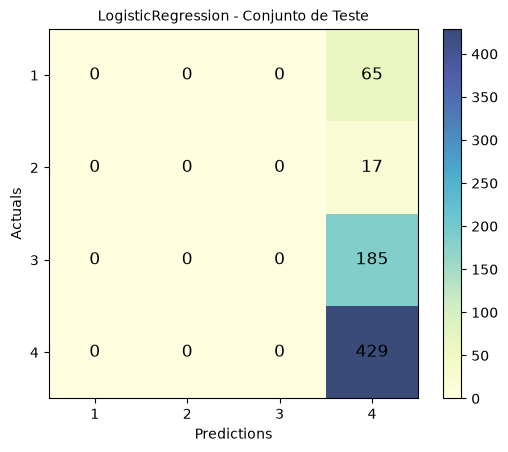


────────────────────────────────────────────────────────────────────────────────
Modelo: KNeighbors
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.15      0.15      0.15        65
           2       0.00      0.00      0.00        17
           3       0.29      0.23      0.26       185
           4       0.62      0.70      0.66       429

    accuracy                           0.51       696
   macro avg       0.27      0.27      0.27       696
weighted avg       0.48      0.51      0.49       696


Matriz de Confusão:
[[ 10   0  10  45]
 [  1   0   3  13]
 [ 19   0  43 123]
 [ 38   1  91 299]]


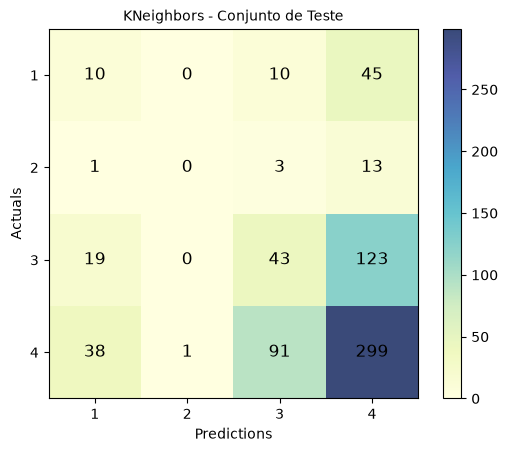


────────────────────────────────────────────────────────────────────────────────
Modelo: SVC
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        65
           2       0.00      0.00      0.00        17
           3       0.00      0.00      0.00       185
           4       0.62      1.00      0.76       429

    accuracy                           0.62       696
   macro avg       0.15      0.25      0.19       696
weighted avg       0.38      0.62      0.47       696


Matriz de Confusão:
[[  0   0   0  65]
 [  0   0   0  17]
 [  0   0   0 185]
 [  0   0   0 429]]


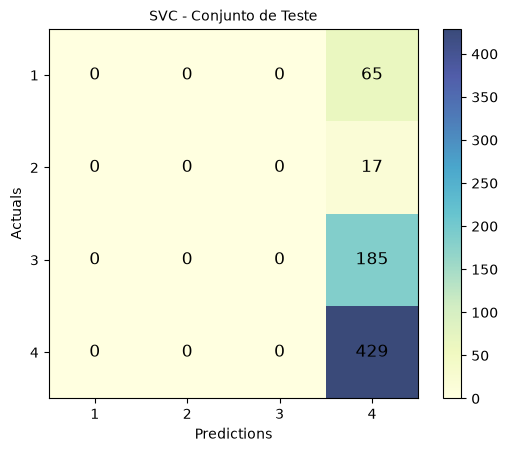


────────────────────────────────────────────────────────────────────────────────
Modelo: DecisionTree
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.12      0.15      0.13        65
           2       0.00      0.00      0.00        17
           3       0.27      0.24      0.25       185
           4       0.64      0.66      0.65       429

    accuracy                           0.48       696
   macro avg       0.26      0.26      0.26       696
weighted avg       0.48      0.48      0.48       696


Matriz de Confusão:
[[ 10   1  13  41]
 [  3   0   4  10]
 [ 29   3  44 109]
 [ 44   4 100 281]]


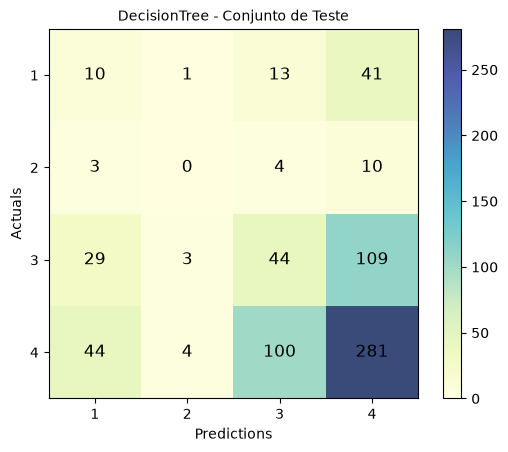


────────────────────────────────────────────────────────────────────────────────
Modelo: ExtraTrees
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.16      0.08      0.10        65
           2       0.00      0.00      0.00        17
           3       0.31      0.16      0.21       185
           4       0.63      0.83      0.72       429

    accuracy                           0.56       696
   macro avg       0.27      0.27      0.26       696
weighted avg       0.48      0.56      0.51       696


Matriz de Confusão:
[[  5   0   9  51]
 [  0   0   2  15]
 [ 11   0  30 144]
 [ 16   0  56 357]]


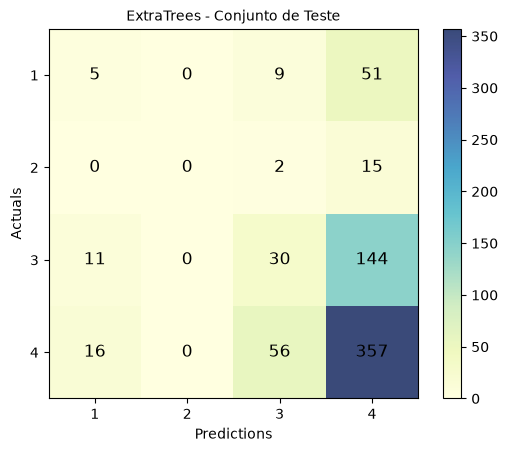


────────────────────────────────────────────────────────────────────────────────
Modelo: RandomForest
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.25      0.05      0.08        65
           2       0.00      0.00      0.00        17
           3       0.33      0.14      0.19       185
           4       0.62      0.88      0.73       429

    accuracy                           0.58       696
   macro avg       0.30      0.27      0.25       696
weighted avg       0.50      0.58      0.51       696


Matriz de Confusão:
[[  3   0   4  58]
 [  0   0   0  17]
 [  5   0  25 155]
 [  4   0  46 379]]


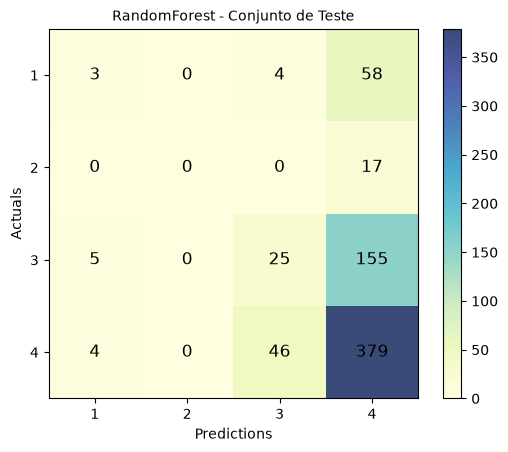


────────────────────────────────────────────────────────────────────────────────
Modelo: GaussianNB
────────────────────────────────────────────────────────────────────────────────

Relatório de Classificação:
              precision    recall  f1-score   support

           1       0.10      0.98      0.18        65
           2       0.00      0.00      0.00        17
           3       0.00      0.00      0.00       185
           4       0.56      0.03      0.07       429

    accuracy                           0.11       696
   macro avg       0.16      0.25      0.06       696
weighted avg       0.35      0.11      0.06       696


Matriz de Confusão:
[[ 64   0   0   1]
 [ 17   0   0   0]
 [173   1   0  11]
 [410   4   0  15]]


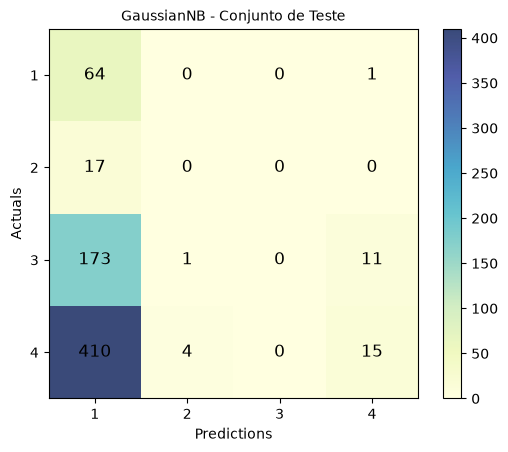


RELATÓRIO RESUMIDO - CONJUNTO DE TESTE
LogisticRegression   | Acc: 0.6164
KNeighbors           | Acc: 0.5057
SVC                  | Acc: 0.6164
DecisionTree         | Acc: 0.4813
ExtraTrees           | Acc: 0.5632
RandomForest         | Acc: 0.5848
GaussianNB           | Acc: 0.1135



In [117]:
test_results_pred = evaluate_on_test(
    caso_pred['X_teste'],
    caso_pred['y_teste'],
    caso_pred['treinados'],
    caso_pred['classes'],
    binary_classification=len(caso_pred['classes']) <= 2,
    result_path=str(pasta_resultados_pred)
)


COMPARAÇÃO: VALIDAÇÃO CRUZADA vs TESTE

             Model CV_Accuracy Test_Accuracy
LogisticRegression      0.5517        0.6164
        KNeighbors      0.5004        0.5057
               SVC      0.6095        0.6164
      DecisionTree      0.4653        0.4813
        ExtraTrees      0.5149        0.5632
      RandomForest      0.5289        0.5848
        GaussianNB      0.2942        0.1135


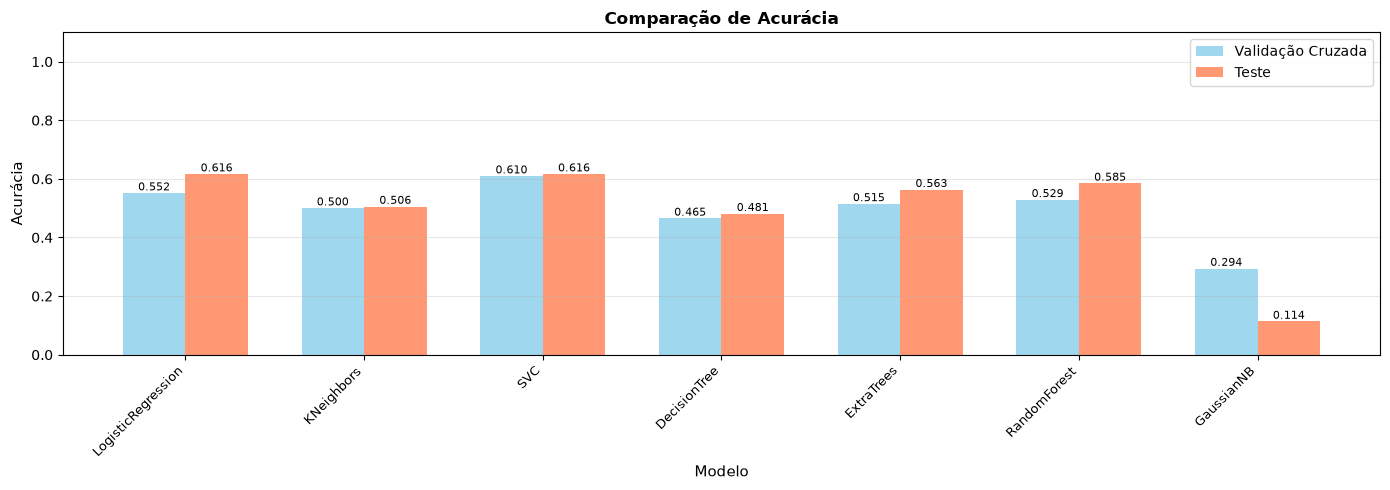


ANÁLISE DE OVERFITTING
LogisticRegression   | CV: 0.5517 | Test: 0.6164 | Diff: -0.0647
KNeighbors           | CV: 0.5004 | Test: 0.5057 | Diff: -0.0053
SVC                  | CV: 0.6095 | Test: 0.6164 | Diff: -0.0069
DecisionTree         | CV: 0.4653 | Test: 0.4813 | Diff: -0.0160
ExtraTrees           | CV: 0.5149 | Test: 0.5632 | Diff: -0.0483
RandomForest         | CV: 0.5289 | Test: 0.5848 | Diff: -0.0559
GaussianNB           | CV: 0.2942 | Test: 0.1135 | Diff: +0.1807


In [118]:
comparacao_pred = compare_train_test_performance(
    cv_pred, test_results_pred, result_path=str(pasta_resultados_pred)
)

## Pruning the tree models

The section grows every tree with scikit-learn's defaults, which means no
pruning at all: `max_depth=None` and `min_samples_leaf=1` let a tree keep
splitting until each leaf is pure. A single anomalous instant then gets a leaf of
its own, which is memorisation rather than learning. D1 shows this in its
smallest possible form: route 3 is the best route in exactly 2 of 3599 instants,
and an unpruned `DecisionTreeClassifier` isolates one of them with a single split
(`h14_h64 > 26.13 -> route 3`), a rule that does not fire for the other one.

Each setting below constrains that in a different way: a floor on how many
samples a leaf must hold, a ceiling on depth, and cost-complexity post-pruning
(`ccp_alpha`), which grows the full tree and then removes the subtrees whose
contribution to purity does not pay for their size.

Besides accuracy and F1-macro, the table reports how many classes the model
actually predicts and the size of the fitted trees, averaged over the ensemble
for the forests. Those two columns are what makes the effect of pruning visible:
accuracy can stay flat while the tree shrinks by two orders of magnitude.

In [126]:
# Pruning settings applied to every tree model. Kept small on purpose: one
#   representative of each family of constraint, so the table stays readable.
PRUNING_GRID = {
    'none (default)': {},
    'min_samples_leaf=3': {'min_samples_leaf': 3},
    'min_samples_leaf=5': {'min_samples_leaf': 5},
    'min_samples_leaf=20': {'min_samples_leaf': 20},
    'max_depth=2': {'max_depth': 2},
    'max_depth=4': {'max_depth': 4},
    'ccp_alpha=0.001': {'ccp_alpha': 0.001},
}

TREE_MODELS = {
    'DecisionTree': tree.DecisionTreeClassifier,
    'ExtraTrees': ExtraTreesClassifier,
    'RandomForest': RandomForestClassifier,
}


def tree_size(estimator):
    """Depth and leaf count of a fitted tree, averaged over the trees of a forest."""
    trees = getattr(estimator, 'estimators_', [estimator])
    return (float(np.mean([t.get_depth() for t in trees])),
            float(np.mean([t.get_n_leaves() for t in trees])))


def evaluate_tree_pruning(largo, horizon_s=H_PRED, fraction=FRACAO_TREINO_PRED,
                          grid=PRUNING_GRID, random_state=RANDOM_STATE_PRED):
    """Evaluate each tree model under each pruning setting, on the same blocks.

    Uses the protocol of the rest of the section (deslocar_alvo followed by
    split_temporal), so the accuracies are directly comparable with the horizon
    table, and returns the two baselines for reference.

    Returns (table, matrices, labels, reference).
    """
    frame, train, test = pt.preparar_treino_teste(largo, horizon_s, fracao_treino=fraction)
    features = colunas_latencia(frame)

    X = frame[features].to_numpy(dtype=float)
    y = frame['melhor_rota'].to_numpy(dtype=int)
    X_train, y_train = X[train.to_numpy()], y[train.to_numpy()]
    X_test, y_test = X[test.to_numpy()], y[test.to_numpy()]
    labels = sorted(set(y_train.tolist()) | set(y_test.tolist()))

    rows, matrices = [], {}
    for model_name, constructor in TREE_MODELS.items():
        for setting_name, params in grid.items():
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('classifier', constructor(random_state=random_state, **params)),
            ])
            pipeline.fit(X_train, y_train)
            y_pred = pipeline.predict(X_test)

            depth, leaves = tree_size(pipeline.named_steps['classifier'])
            rows.append({
                'model': model_name,
                'pruning': setting_name,
                'accuracy': accuracy_score(y_test, y_pred),
                'f1_macro': f1_score(y_test, y_pred, average='macro', zero_division=0),
                'classes_predicted': len(set(y_pred.tolist())),
                'depth': round(depth, 1),
                'leaves': round(leaves, 1),
            })
            matrices[(model_name, setting_name)] = confusion_matrix(
                y_test, y_pred, labels=labels
            )

    table = pd.DataFrame(rows).set_index(['model', 'pruning'])

    persistence = float(
        (frame.loc[test, pt.COLUNA_ALVO_ATUAL].to_numpy(dtype=int) == y_test).mean()
    )
    majority_class = int(pd.Series(y_train).value_counts().idxmax())
    reference = {
        'n_test': len(y_test),
        'persistence': persistence,
        'majority': float((y_test == majority_class).mean()),
        'majority_class': majority_class,
    }
    return table, matrices, labels, reference


pruning_table, pruning_matrices, pruning_labels, pruning_reference = \
    evaluate_tree_pruning(largo_pred)

print(f"{DATASET_PRED}, H={H_PRED}s | test block: {pruning_reference['n_test']} instants")
print(f"reference | persistence {pruning_reference['persistence']:.4f} | "
      f"majority class {pruning_reference['majority_class']}: "
      f"{pruning_reference['majority']:.4f}")
pruning_table.round(4)

deslocar_alvo(H=30s): descartando 30/3663 linha(s) sem observacao em t+30s
D3, H=30s | test block: 696 instants
reference | persistence 0.4411 | majority class 4: 0.6164


accuracy  f1_macro  classes_predicted  \
model        pruning                                                      
DecisionTree none (default)         0.4813    0.2582                  4   
             min_samples_leaf=3     0.4684    0.2598                  4   
             min_samples_leaf=5     0.4770    0.2659                  3   
             min_samples_leaf=20    0.5661    0.2490                  3   
             max_depth=2            0.6164    0.1907                  1   
             max_depth=4            0.6135    0.1901                  2   
             ccp_alpha=0.001        0.6164    0.1907                  1   
ExtraTrees   none (default)         0.5632    0.2582                  3   
             min_samples_leaf=3     0.6164    0.1907                  1   
             min_samples_leaf=5     0.6164    0.1907                  1   
             min_samples_leaf=20    0.6164    0.1907                  1   
             max_depth=2            0.6164    0.1907                  1   
             max_depth=4            0.6164    0.1907                  1   
             ccp_alpha=0.001        0.6164    0.1907                  1   
RandomForest none (default)         0.5848    0.2501                  3   
             min_samples_leaf=3     0.5905    0.2108                  3   
             min_samples_leaf=5     0.6063    0.2112                  2   
             min_samples_leaf=20    0.6164    0.1907                  1   
             max_depth=2            0.6164    0.1907                  1   
             max_depth=4            0.6164    0.1907                  1   
             ccp_alpha=0.001        0.6049    0.1980                  2   

                                  depth  leaves  
model        pruning                             
DecisionTree none (default)        42.0   957.0  
             min_samples_leaf=3    35.0   591.0  
             min_samples_leaf=5    33.0   391.0  
             min_samples_leaf=20   18.0   106.0  
             max_depth=2            2.0     4.0  
             max_depth=4            4.0    16.0  
             ccp_alpha=0.001       11.0    21.0  
ExtraTrees   none (default)        54.3  1893.1  
             min_samples_leaf=3    32.1   325.6  
             min_samples_leaf=5    22.0   132.7  
             min_samples_leaf=20    9.3    21.1  
             max_depth=2            2.0     4.0  
             max_depth=4            4.0    14.2  
             ccp_alpha=0.001        4.8     6.8  
RandomForest none (default)        34.2   733.6  
             min_samples_leaf=3    27.8   396.6  
             min_samples_leaf=5    25.0   261.1  
             min_samples_leaf=20   15.8    70.0  
             max_depth=2            2.0     4.0  
             max_depth=4            4.0    14.9  
             ccp_alpha=0.001       24.2   138.6

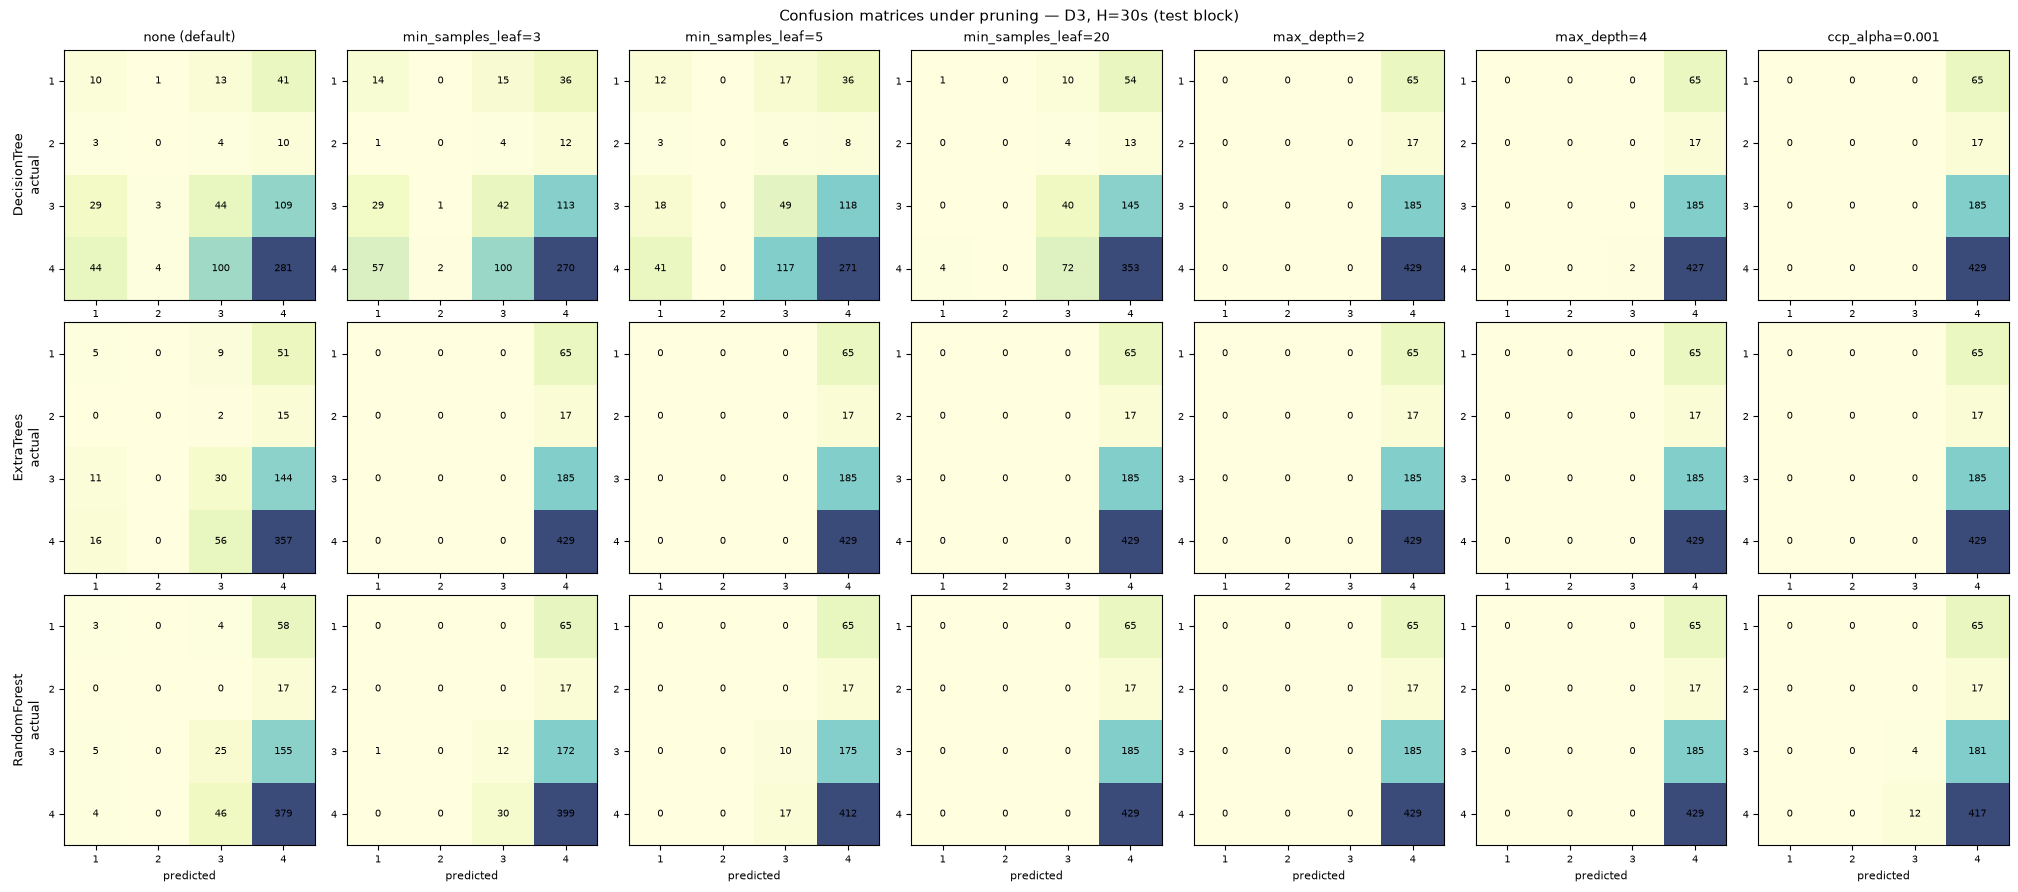

In [127]:
def plot_pruning_confusion_matrices(matrices, labels, path=None):
    """Confusion matrices of the pruning study: one row per model, one column per setting.

    Rows of each matrix are the actual routes and columns the predicted ones, the
    same orientation as plot_matrix. A column that concentrates every count is a
    model that collapsed into predicting a single route.
    """
    models = list(dict.fromkeys(model for model, _ in matrices))
    settings = list(dict.fromkeys(setting for _, setting in matrices))

    fig, axes = plt.subplots(
        len(models), len(settings),
        figsize=(2.9 * len(settings), 3.0 * len(models)),
        squeeze=False,
    )

    for row, model_name in enumerate(models):
        for column, setting_name in enumerate(settings):
            eixo = axes[row][column]
            matriz = matrices[(model_name, setting_name)]
            eixo.matshow(matriz, cmap=plt.cm.YlGnBu, alpha=0.8)

            for i in range(matriz.shape[0]):
                for j in range(matriz.shape[1]):
                    eixo.text(j, i, matriz[i, j], ha='center', va='center', fontsize=7)

            eixo.set_xticks(range(len(labels)), [str(l) for l in labels], fontsize=7)
            eixo.set_yticks(range(len(labels)), [str(l) for l in labels], fontsize=7)
            eixo.xaxis.set_ticks_position('bottom')
            if row == 0:
                eixo.set_title(setting_name, fontsize=9)
            if column == 0:
                eixo.set_ylabel(f'{model_name}\nactual', fontsize=9)
            if row == len(models) - 1:
                eixo.set_xlabel('predicted', fontsize=8)

    fig.suptitle(
        f'Confusion matrices under pruning — {DATASET_PRED}, H={H_PRED}s (test block)',
        fontsize=11,
    )
    plt.tight_layout()
    if path is not None:
        plt.savefig(path, dpi=300, bbox_inches='tight')
    plt.show()


plot_pruning_confusion_matrices(
    pruning_matrices, pruning_labels,
    path=pasta_resultados_pred / f'pruning_confusion_matrices_H{H_PRED}.png',
)